In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heterogeneity+activity+recognition.zip to heterogeneity+activity+recognition.zip


In [ ]:
import os
import shutil

os.makedirs('/content/drive/MyDrive/ML_Project', exist_ok=True)

shutil.copy(
    '/content/heterogeneity+activity+recognition.zip',
    '/content/drive/MyDrive/ML_Project/heterogeneity+activity+recognition.zip'
)

'/content/drive/MyDrive/ML_Project/heterogeneity+activity+recognition.zip'

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/ML_Project/heterogeneity+activity+recognition.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    files = zip_ref.namelist()

print(f"Number of files: {len(files)}")

for file in files[:30]:
    print(file)

Number of files: 2
Activity recognition exp.zip
Still exp.zip


In [ ]:
import zipfile

outer_zip_path = '/content/drive/MyDrive/ML_Project/heterogeneity+activity+recognition.zip'

with zipfile.ZipFile(outer_zip_path, 'r') as outer_zip:

    # Load the Activity recognition exp.zip file into memory.
    activity_zip_data = outer_zip.read('Activity recognition exp.zip')

# Temporarily save the inner ZIP file to Drive.
activity_zip_path = '/content/drive/MyDrive/ML_Project/Activity recognition exp.zip'

with open(activity_zip_path, 'wb') as f:
    f.write(activity_zip_data)

print("Activity recognition ZIP ready:")
print(activity_zip_path)

Activity recognition ZIP ready:
/content/drive/MyDrive/ML_Project/Activity recognition exp.zip


In [ ]:
import zipfile

with zipfile.ZipFile(activity_zip_path, 'r') as zip_ref:
    activity_files = zip_ref.namelist()

print(f"Number of files: {len(activity_files)}")

for file in activity_files[:50]:
    print(file)

Number of files: 11
Activity recognition exp/
Activity recognition exp/.DS_Store
__MACOSX/
__MACOSX/Activity recognition exp/
__MACOSX/Activity recognition exp/._.DS_Store
Activity recognition exp/Phones_accelerometer.csv
Activity recognition exp/Phones_gyroscope.csv
Activity recognition exp/readme.txt
__MACOSX/Activity recognition exp/._readme.txt
Activity recognition exp/Watch_accelerometer.csv
Activity recognition exp/Watch_gyroscope.csv


In [ ]:
import zipfile
import os

activity_zip_path = '/content/drive/MyDrive/ML_Project/Activity recognition exp.zip'
extract_path = '/content/drive/MyDrive/ML_Project/data'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(activity_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("The dataset was extracted.")

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

The dataset was extracted.
/content/drive/MyDrive/ML_Project/data/Activity recognition exp/.DS_Store
/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv
/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_gyroscope.csv
/content/drive/MyDrive/ML_Project/data/Activity recognition exp/readme.txt
/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Watch_accelerometer.csv
/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Watch_gyroscope.csv
/content/drive/MyDrive/ML_Project/data/__MACOSX/Activity recognition exp/._.DS_Store
/content/drive/MyDrive/ML_Project/data/__MACOSX/Activity recognition exp/._readme.txt


In [ ]:
import os

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

file_size_mb = os.path.getsize(csv_path) / (1024 ** 2)

print(f"File size: {file_size_mb:.2f} MB")

File size: 1232.01 MB


In [ ]:
import pandas as pd

df_sample = pd.read_csv(csv_path, nrows=10000)

print("Row number:", len(df_sample))
print("Column Number:", len(df_sample.columns))

print("\nColumns:")
print(df_sample.columns.tolist())


<>:8: SyntaxWarning: invalid escape sequence '\C'
<>:8: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_739/4056694465.py:8: SyntaxWarning: invalid escape sequence '\C'
  print("\Columns:")


Row number: 10000
Column Number: 10
\Columns:
['Index', 'Arrival_Time', 'Creation_Time', 'x', 'y', 'z', 'User', 'Model', 'Device', 'gt']


In [ ]:
df_sample.head()

,Index,Arrival_Time,Creation_Time,x,y,z,User,Model,Device,gt
0,0,1424696633908,1424696631913248572,-5.958191,0.688065,8.135345,a,nexus4,nexus4_1,stand
1,1,1424696633909,1424696631918283972,-5.952240,0.670212,8.136536,a,nexus4,nexus4_1,stand
2,2,1424696633918,1424696631923288855,-5.995087,0.653549,8.204376,a,nexus4,nexus4_1,stand
3,3,1424696633919,1424696631928385290,-5.942718,0.676163,8.128204,a,nexus4,nexus4_1,stand
4,4,1424696633929,1424696631933420691,-5.991516,0.641647,8.135345,a,nexus4,nexus4_1,stand


In [ ]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          10000 non-null  int64  
 1   Arrival_Time   10000 non-null  int64  
 2   Creation_Time  10000 non-null  int64  
 3   x              10000 non-null  float64
 4   y              10000 non-null  float64
 5   z              10000 non-null  float64
 6   User           10000 non-null  object 
 7   Model          10000 non-null  object 
 8   Device         10000 non-null  object 
 9   gt             10000 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB


In [ ]:
print("Users:")
print(df_sample['User'].unique())

print("\nModels:")
print(df_sample['Model'].unique())

print("\nDevices:")
print(df_sample['Device'].unique())

print("\nActivities:")
print(df_sample['gt'].unique())

Users:
['a']

Models:
['nexus4']

Devices:
['nexus4_1']

Activities:
['stand']


In [ ]:
print("User count:", df_sample['User'].nunique())
print("Model count:", df_sample['Model'].nunique())
print("Device count:", df_sample['Device'].nunique())
print("Activity count:", df_sample['gt'].nunique())

User count: 1
Model count: 1
Device count: 1
Activity count: 1


In [ ]:
print("Missing gt:", df_sample['gt'].isna().sum())

Missing gt: 0


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

users = set()
models = set()
devices = set()
activities = set()

total_rows = 0
missing_gt = 0

for chunk in pd.read_csv(
    csv_path,
    usecols=['User', 'Model', 'Device', 'gt'],
    chunksize=500_000
):
    total_rows += len(chunk)

    users.update(chunk['User'].dropna().unique())
    models.update(chunk['Model'].dropna().unique())
    devices.update(chunk['Device'].dropna().unique())
    activities.update(chunk['gt'].dropna().unique())

    missing_gt += chunk['gt'].isna().sum()

print("Total rows:", total_rows)

print("\nUsers:")
print(sorted(users))

print("\nModels:")
print(sorted(models))

print("\nDevices:")
print(sorted(devices))

print("\nActivities:")
print(sorted(activities))

print("\nNumber of users:", len(users))
print("Number of models:", len(models))
print("Number of devices:", len(devices))
print("Number of activities:", len(activities))

print("\nMissing gt:", missing_gt)

Total rows: 13062475

Users:
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

Models:
['nexus4', 's3', 's3mini', 'samsungold']

Devices:
['nexus4_1', 'nexus4_2', 's3_1', 's3_2', 's3mini_1', 's3mini_2', 'samsungold_1', 'samsungold_2']

Activities:
['bike', 'sit', 'stairsdown', 'stairsup', 'stand', 'walk']

Number of users: 9
Number of models: 4
Number of devices: 8
Number of activities: 6

Missing gt: 1783200


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

model_counts = {}
device_counts = {}
activity_counts = {}
user_counts = {}

for chunk in pd.read_csv(
    csv_path,
    usecols=['User', 'Model', 'Device', 'gt'],
    chunksize=500_000
):

    # Model
    counts = chunk['Model'].value_counts()
    for key, value in counts.items():
        model_counts[key] = model_counts.get(key, 0) + value

    # Device
    counts = chunk['Device'].value_counts()
    for key, value in counts.items():
        device_counts[key] = device_counts.get(key, 0) + value

    # Activity
    counts = chunk['gt'].value_counts(dropna=False)
    for key, value in counts.items():
        activity_counts[key] = activity_counts.get(key, 0) + value

    # User
    counts = chunk['User'].value_counts()
    for key, value in counts.items():
        user_counts[key] = user_counts.get(key, 0) + value


print("MODEL COUNTS")
print(pd.Series(model_counts).sort_values(ascending=False))

print("\nDEVICE COUNTS")
print(pd.Series(device_counts).sort_values(ascending=False))

print("\nACTIVITY COUNTS")
print(pd.Series(activity_counts).sort_values(ascending=False))

print("\nUSER COUNTS")
print(pd.Series(user_counts).sort_values(ascending=False))

MODEL COUNTS
nexus4        6240983
s3            2959749
samsungold    2226564
s3mini        1635179
dtype: int64

DEVICE COUNTS
nexus4_2        3149186
nexus4_1        3091797
s3_2            1557683
s3mini_1        1539476
s3_1            1402066
samsungold_1    1113984
samsungold_2    1112580
s3mini_2          95703
dtype: int64

ACTIVITY COUNTS
walk          2192401
sit           1991919
stand         1851492
bike          1845557
NaN           1783200
stairsup      1782010
stairsdown    1615896
dtype: int64

USER COUNTS
e    1614999
g    1587697
i    1557737
b    1548768
f    1384531
a    1362520
h    1342301
d    1337124
c    1326798
dtype: int64


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

user_device_counts = {}

for chunk in pd.read_csv(
    csv_path,
    usecols=['User', 'Model', 'Device'],
    chunksize=500_000
):

    counts = (
        chunk
        .groupby(['User', 'Model', 'Device'])
        .size()
    )

    for key, value in counts.items():
        user_device_counts[key] = user_device_counts.get(key, 0) + value


user_device_df = (
    pd.Series(user_device_counts, name='Count')
    .reset_index()
)

user_device_df.columns = ['User', 'Model', 'Device', 'Count']

user_device_df = user_device_df.sort_values(
    ['User', 'Model', 'Device']
)

user_device_df

,User,Model,Device,Count
0,a,nexus4,nexus4_1,323817
1,a,nexus4,nexus4_2,323008
2,a,s3,s3_1,165911
3,a,s3,s3_2,162006
4,a,s3mini,s3mini_1,159318
...,...,...,...,...
66,i,s3,s3_2,182149
67,i,s3mini,s3mini_1,180512
68,i,s3mini,s3mini_2,11323
69,i,samsungold,samsungold_1,130203


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

activity_device_counts = {}

for chunk in pd.read_csv(
    csv_path,
    usecols=['Model', 'gt'],
    chunksize=500_000
):

    chunk = chunk.dropna(subset=['gt'])

    counts = (
        chunk
        .groupby(['Model', 'gt'])
        .size()
    )

    for key, value in counts.items():
        activity_device_counts[key] = activity_device_counts.get(key, 0) + value


activity_device_df = (
    pd.Series(activity_device_counts, name='Count')
    .reset_index()
)

activity_device_df.columns = ['Model', 'Activity', 'Count']

activity_device_df

,Model,Activity,Count
0,nexus4,bike,863713
1,nexus4,sit,984731
2,nexus4,stairsdown,749063
3,nexus4,stairsup,836590
4,nexus4,stand,910802
5,nexus4,walk,1060333
6,s3,bike,410012
7,s3,sit,475899
8,s3,stairsdown,353259
9,s3,stairsup,398760


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

sample = pd.read_csv(
    csv_path,
    usecols=['Arrival_Time', 'Creation_Time', 'x', 'y', 'z', 'User', 'Model', 'Device', 'gt'],
    nrows=100000
)

print("Shape:", sample.shape)
print("\nİlk zaman değerleri:")
print(sample[['Arrival_Time', 'Creation_Time']].head(10))

print("\nCreation_Time farkları:")
print(sample['Creation_Time'].diff().dropna().head(20))

print("\nArrival_Time farkları:")
print(sample['Arrival_Time'].diff().dropna().head(20))

Shape: (100000, 9)

İlk zaman değerleri:
    Arrival_Time        Creation_Time
0  1424696633908  1424696631913248572
1  1424696633909  1424696631918283972
2  1424696633918  1424696631923288855
3  1424696633919  1424696631928385290
4  1424696633929  1424696631933420691
5  1424696633929  1424696631938456091
6  1424696633938  1424696631943522009
7  1424696633939  1424696631948496374
8  1424696633951  1424696631953592810
9  1424696633952  1424696631960428747

Creation_Time farkları:
1     5035400.0
2     5004883.0
3     5096435.0
4     5035401.0
5     5035400.0
6     5065918.0
7     4974365.0
8     5096436.0
9     6835937.0
10    3234864.0
11    5249023.0
12    4821778.0
13    5035400.0
14    5035400.0
15    5035401.0
16    5035400.0
17    5187988.0
18    4882813.0
19    6500244.0
20    3570557.0
Name: Creation_Time, dtype: float64

Arrival_Time farkları:
1      1.0
2      9.0
3      1.0
4     10.0
5      0.0
6      9.0
7      1.0
8     12.0
9      1.0
10     7.0
11     1.0
12     6.0
13  

In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

sample = pd.read_csv(
    csv_path,
    usecols=['Creation_Time'],
    nrows=100000
)

time_diff_ms = sample['Creation_Time'].diff().dropna() / 1_000_000

print("Ortalama zaman farkı (ms):", time_diff_ms.mean())
print("Medyan zaman farkı (ms):", time_diff_ms.median())
print("Minimum zaman farkı (ms):", time_diff_ms.min())
print("Maksimum zaman farkı (ms):", time_diff_ms.max())

print("\nYüzdelikler:")
print(time_diff_ms.quantile([0.01, 0.05, 0.50, 0.95, 0.99]))

Ortalama zaman farkı (ms): 5.392214798317869
Medyan zaman farkı (ms): 5.0354
Minimum zaman farkı (ms): -131071989.959717
Maksimum zaman farkı (ms): 131072005.109067

Yüzdelikler:
0.01    -6.744385
0.05     2.960205
0.50     5.035400
0.95    10.040283
0.99    12.024536
Name: Creation_Time, dtype: float64


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

sample = pd.read_csv(
    csv_path,
    usecols=[
        'Creation_Time',
        'User',
        'Model',
        'Device',
        'gt'
    ],
    nrows=100000
)

print("User distribution:")
print(sample['User'].value_counts())

print("\nModel distribution:")
print(sample['Model'].value_counts())

print("\nDevice distribution:")
print(sample['Device'].value_counts())

print("\nActivity distribution:")
print(sample['gt'].value_counts(dropna=False))

User distribution:
User
a    100000
Name: count, dtype: int64

Model distribution:
Model
nexus4    100000
Name: count, dtype: int64

Device distribution:
Device
nexus4_1    100000
Name: count, dtype: int64

Activity distribution:
gt
stand    55163
sit      44172
NaN        665
Name: count, dtype: int64


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

sample = pd.read_csv(
    csv_path,
    usecols=['Creation_Time', 'User', 'Model', 'Device', 'gt'],
    nrows=500000
)

# Find activity changes in the first 500,000 rows.
activity_change = sample['gt'].ne(sample['gt'].shift())

changes = sample.loc[
    activity_change,
    ['Creation_Time', 'User', 'Model', 'Device', 'gt']
]

print("Number of activity changes:", len(changes))
print("\nFirst 30 activity changes:")
print(changes.head(30).to_string(index=False))

Number of activity changes: 51863

First 30 activity changes:
      Creation_Time User  Model   Device    gt
1424696631913248572    a nexus4 nexus4_1 stand
1424696935005288835    a nexus4 nexus4_1   NaN
1424696935010498902    a nexus4 nexus4_1   NaN
1424696935021576782    a nexus4 nexus4_1   NaN
1424696935015595337    a nexus4 nexus4_1   NaN
1424696935025635620    a nexus4 nexus4_1   NaN
1424696935032929322    a nexus4 nexus4_1   NaN
1424696935035950562    a nexus4 nexus4_1   NaN
1424696935040741822    a nexus4 nexus4_1   NaN
1424696935045777222    a nexus4 nexus4_1   NaN
1424696935050843140    a nexus4 nexus4_1   NaN
1424696935055848023    a nexus4 nexus4_1   NaN
1424696935060883423    a nexus4 nexus4_1   NaN
1424696935065918823    a nexus4 nexus4_1   NaN
1424696935070954224    a nexus4 nexus4_1   NaN
1424696935076020142    a nexus4 nexus4_1   NaN
1424696935081055542    a nexus4 nexus4_1   NaN
1424696935086060425    a nexus4 nexus4_1   NaN
1424696935092835327    a nexus4 nexus4_1   Na

In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

sample = pd.read_csv(
    csv_path,
    usecols=[
        'Creation_Time',
        'x',
        'y',
        'z',
        'User',
        'Model',
        'Device',
        'gt'
    ],
    nrows=500000
)

#Only retrieve tagged records.
labeled_sample = sample.dropna(subset=['gt']).copy()

print("Total sample:", len(sample))
print("Labeled example:", len(labeled_sample))
print("Unlabeled sample:", sample['gt'].isna().sum())

print("\nTagged activity distribution:")
print(labeled_sample['gt'].value_counts())

print("\nFirst labeled records:")
print(
    labeled_sample[
        ['Creation_Time', 'User', 'Model', 'Device', 'gt']
    ].head(20).to_string(index=False)
)

Total sample: 500000
Labeled example: 448154
Unlabeled sample: 51846

Tagged activity distribution:
gt
sit           119549
stand         111929
walk           91836
stairsdown     44990
stairsup       43174
bike           36676
Name: count, dtype: int64

First labeled records:
      Creation_Time User  Model   Device    gt
1424696631913248572    a nexus4 nexus4_1 stand
1424696631918283972    a nexus4 nexus4_1 stand
1424696631923288855    a nexus4 nexus4_1 stand
1424696631928385290    a nexus4 nexus4_1 stand
1424696631933420691    a nexus4 nexus4_1 stand
1424696631938456091    a nexus4 nexus4_1 stand
1424696631943522009    a nexus4 nexus4_1 stand
1424696631948496374    a nexus4 nexus4_1 stand
1424696631953592810    a nexus4 nexus4_1 stand
1424696631960428747    a nexus4 nexus4_1 stand
1424696631963663611    a nexus4 nexus4_1 stand
1424696631968912634    a nexus4 nexus4_1 stand
1424696631973734412    a nexus4 nexus4_1 stand
1424696631978769812    a nexus4 nexus4_1 stand
1424696631983805

In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

sample = pd.read_csv(
    csv_path,
    usecols=[
        'Creation_Time',
        'x',
        'y',
        'z',
        'User',
        'Model',
        'Device',
        'gt'
    ],
    nrows=100000
)

# Only labeled records
sample = sample.dropna(subset=['gt']).copy()

# Convert time to seconds
sample['Time_sec'] = sample['Creation_Time'] / 1_000_000_000

# Calculate the duration of the first activity block.
first_activity = sample['gt'].iloc[0]

first_block = sample[sample['gt'] == first_activity]

print("First activity:", first_activity)
print("Number of initial activity registrations:", len(first_block))
print(
    "Initial activity time interval (seconds):",
    first_block['Time_sec'].iloc[-1] - first_block['Time_sec'].iloc[0]
)

print("\nFirst 10 time intervals (ms):")
print(
    sample['Time_sec']
    .diff()
    .dropna()
    .head(10)
    .mul(1000)
)

First activity: stand
Number of initial activity registrations: 55163
Initial activity time interval (seconds): 298.12719655036926

First 10 time intervals (ms):
1     5.035400
2     5.004883
3     5.096436
4     5.035639
5     5.035162
6     5.065918
7     4.974365
8     5.096436
9     6.835938
10    3.234863
Name: Time_sec, dtype: float64


In [ ]:
import pandas as pd
import numpy as np

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

sample = pd.read_csv(
    csv_path,
    usecols=[
        'Creation_Time',
        'x',
        'y',
        'z',
        'User',
        'Model',
        'Device',
        'gt'
    ],
    nrows=500000
)

# Remove untagged records
sample = sample.dropna(subset=['gt']).copy()

# Convert time to seconds
sample['Time_sec'] = sample['Creation_Time'] / 1_000_000_000

# Same user + device + activity groups
sample = sample.sort_values(
    ['User', 'Model', 'Device', 'gt', 'Creation_Time']
)

WINDOW_SECONDS = 3

windows = []

for (user, model, device, activity), group in sample.groupby(
    ['User', 'Model', 'Device', 'gt']
):

    start_time = group['Time_sec'].iloc[0]
    window_id = 0

    for _, row in group.iterrows():

        current_time = row['Time_sec']

        if current_time - start_time < WINDOW_SECONDS:
            windows.append({
                'User': user,
                'Model': model,
                'Device': device,
                'Activity': activity,
                'Window_ID': window_id
            })
        else:
            start_time = current_time
            window_id += 1

            windows.append({
                'User': user,
                'Model': model,
                'Device': device,
                'Activity': activity,
                'Window_ID': window_id
            })

windows_df = pd.DataFrame(windows)

print("Created window records:", len(windows_df))

print("\nInitial records:")
print(windows_df.head())

print("\nWindow records per activity:")
print(windows_df['Activity'].value_counts())

Created window records: 448154

Initial records:
  User   Model    Device Activity  Window_ID
0    a  nexus4  nexus4_1     bike          0
1    a  nexus4  nexus4_1     bike          0
2    a  nexus4  nexus4_1     bike          0
3    a  nexus4  nexus4_1     bike          0
4    a  nexus4  nexus4_1     bike          0

Window records per activity:
Activity
sit           119549
stand         111929
walk           91836
stairsdown     44990
stairsup       43174
bike           36676
Name: count, dtype: int64


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

sample = pd.read_csv(
    csv_path,
    usecols=[
        'Creation_Time',
        'x',
        'y',
        'z',
        'User',
        'Model',
        'Device',
        'gt'
    ],
    nrows=100000
)

# Labeled records only
sample = sample.dropna(subset=['gt']).copy()

# Convert time to seconds
sample['Time_sec'] = sample['Creation_Time'] / 1_000_000_000

# Get the first activity block
activity = sample['gt'].iloc[0]

group = sample[sample['gt'] == activity].copy()

start_time = group['Time_sec'].iloc[0]

# First 3-second window
window = group[
    (group['Time_sec'] >= start_time) &
    (group['Time_sec'] < start_time + 3)
]

print("Activity:", activity)
print("Window duration:",
      window['Time_sec'].iloc[-1] - window['Time_sec'].iloc[0],
      "seconds")

print("Sensor record count:", len(window))

print("\nStart time:", window['Time_sec'].iloc[0])
print("End time:", window['Time_sec'].iloc[-1])

print("\nSample x/y/z values:")
print(window[['x', 'y', 'z']].head())

Activity: stand
Window duration: 2.9985556602478027 seconds
Sensor record count: 596

Start time: 1424696631.9132485
End time: 1424696634.9118042

Sample x/y/z values:
          x         y         z
0 -5.958191  0.688065  8.135345
1 -5.952240  0.670212  8.136536
2 -5.995087  0.653549  8.204376
3 -5.942718  0.676163  8.128204
4 -5.991516  0.641647  8.135345


In [ ]:
import pandas as pd
import numpy as np

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

sample = pd.read_csv(
    csv_path,
    usecols=[
        'Creation_Time',
        'x',
        'y',
        'z',
        'User',
        'Model',
        'Device',
        'gt'
    ],
    nrows=10000
)

sample = sample.dropna(subset=['gt']).copy()

sample['Time_sec'] = sample['Creation_Time'] / 1_000_000_000

sample = sample.sort_values('Creation_Time')

WINDOW_SECONDS = 3

features = []

for (user, model, device, activity), group in sample.groupby(
    ['User', 'Model', 'Device', 'gt']
):

    group = group.sort_values('Time_sec').reset_index(drop=True)

    start_idx = 0
    window_id = 0

    while start_idx < len(group):

        start_time = group.loc[start_idx, 'Time_sec']

        end_idx = start_idx

        while (
            end_idx < len(group)
            and group.loc[end_idx, 'Time_sec'] < start_time + WINDOW_SECONDS
        ):
            end_idx += 1

        window = group.iloc[start_idx:end_idx]

        if len(window) < 100:
            break

        magnitude = np.sqrt(
            window['x'] ** 2 +
            window['y'] ** 2 +
            window['z'] ** 2
        )

        features.append({
            'User': user,
            'Model': model,
            'Device': device,
            'Window_ID': window_id,

            'mean_x': window['x'].mean(),
            'std_x': window['x'].std(),
            'min_x': window['x'].min(),
            'max_x': window['x'].max(),

            'mean_y': window['y'].mean(),
            'std_y': window['y'].std(),
            'min_y': window['y'].min(),
            'max_y': window['y'].max(),

            'mean_z': window['z'].mean(),
            'std_z': window['z'].std(),
            'min_z': window['z'].min(),
            'max_z': window['z'].max(),

            'mean_magnitude': magnitude.mean(),
            'std_magnitude': magnitude.std(),
            'min_magnitude': magnitude.min(),
            'max_magnitude': magnitude.max(),

            'Activity': activity
        })

        window_id += 1
        start_idx = end_idx

features_df = pd.DataFrame(features)

print("Number of windows:", len(features_df))
print("Number of features:", features_df.shape[1])

print("\nFeature dataset:")
display(features_df.head())

print("\nActivity distribution:")
print(features_df['Activity'].value_counts())

Number of windows: 3
Number of features: 21

Feature dataset:


,User,Model,Device,Window_ID,mean_x,std_x,min_x,max_x,mean_y,std_y,...,max_y,mean_z,std_z,min_z,max_z,mean_magnitude,std_magnitude,min_magnitude,max_magnitude,Activity
0,a,nexus4,nexus4_1,0,-5.803183,0.068351,-6.005798,-5.647552,0.753976,0.074294,...,0.980850,8.214351,0.058527,8.034180,8.376953,10.086278,0.039680,9.970114,10.216889,stand
1,a,nexus4,nexus4_1,1,-5.808262,0.045074,-5.920105,-5.701111,0.760203,0.034679,...,0.864212,8.213435,0.042842,8.112732,8.331726,10.088498,0.039786,9.977723,10.203897,stand
2,a,nexus4,nexus4_1,2,-5.712857,0.049135,-5.860596,-5.553528,0.457137,0.040851,...,0.578568,8.303855,0.070068,8.069885,8.526916,10.089859,0.058563,9.883584,10.267418,stand



Activity distribution:
Activity
stand    3
Name: count, dtype: int64


In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'

model_counts = {}

for chunk_number, chunk in enumerate(
    pd.read_csv(
        csv_path,
        usecols=['Model'],
        chunksize=500_000
    ),
    start=1
):

    counts = chunk['Model'].value_counts()

    model_counts[chunk_number] = counts.to_dict()

    print(f"\nChunk {chunk_number}:")
    print(counts)


Chunk 1:
Model
nexus4    500000
Name: count, dtype: int64

Chunk 2:
Model
s3        327917
nexus4    146825
s3mini     25258
Name: count, dtype: int64

Chunk 3:
Model
samsungold    219892
s3mini        142628
nexus4        137480
Name: count, dtype: int64

Chunk 4:
Model
nexus4    500000
Name: count, dtype: int64

Chunk 5:
Model
s3        367116
nexus4     92438
s3mini     40446
Name: count, dtype: int64

Chunk 6:
Model
samsungold    270776
s3mini        140512
nexus4         88712
Name: count, dtype: int64

Chunk 7:
Model
nexus4    500000
Name: count, dtype: int64

Chunk 8:
Model
s3        315594
s3mini    155877
nexus4     28529
Name: count, dtype: int64

Chunk 9:
Model
nexus4        261914
samsungold    230189
s3mini          7897
Name: count, dtype: int64

Chunk 10:
Model
nexus4    388045
s3        111955
Name: count, dtype: int64

Chunk 11:
Model
s3            203159
s3mini        156015
samsungold    140826
Name: count, dtype: int64

Chunk 12:
Model
nexus4        424790
samsungo

In [ ]:
import polars as pl
import os

csv_path = '/content/drive/MyDrive/ML_Project/data/Activity recognition exp/Phones_accelerometer.csv'
labeled_path = '/content/drive/MyDrive/ML_Project/labeled_sensor_data.parquet'

columns = [
    'Creation_Time',
    'x',
    'y',
    'z',
    'User',
    'Model',
    'Device',
    'gt'
]

df = (
    pl.scan_csv(
        csv_path,
        has_header=True
    )
    .select(columns)
    .filter(pl.col('gt').is_not_null())
    .with_columns(
        (pl.col('Creation_Time') / 1_000_000_000).alias('Time_sec')
    )
    .sort([
        'User',
        'Model',
        'Device',
        'Creation_Time'
    ])
)

df.collect().write_parquet(labeled_path)

print("Labeled sensor data created.")
print("Output:", labeled_path)

Labeled sensor data created.
Output: /content/drive/MyDrive/ML_Project/labeled_sensor_data.parquet


In [ ]:
import polars as pl
import os

labeled_path = '/content/drive/MyDrive/ML_Project/labeled_sensor_data.parquet'

df = pl.read_parquet(labeled_path)

print("Number of rows:", df.height)
print("Number of columns:", df.width)

print("\nColumns:")
print(df.columns)

print("\nModel distribution:")
print(
    df.group_by('Model')
      .len()
      .sort('Model')
)

print("\nActivity distribution:")
print(
    df.group_by('gt')
      .len()
      .sort('gt')
)

print("\nDevice distribution:")
print(
    df.group_by('Device')
      .len()
      .sort('Device')
)

print("\nFile size (MB):",
      round(os.path.getsize(labeled_path) / (1024 ** 2), 2))

Number of rows: 13062475
Number of columns: 9

Columns:
['Creation_Time', 'x', 'y', 'z', 'User', 'Model', 'Device', 'gt', 'Time_sec']

Model distribution:
shape: (4, 2)
┌────────────┬─────────┐
│ Model      ┆ len     │
│ ---        ┆ ---     │
│ str        ┆ u32     │
╞════════════╪═════════╡
│ nexus4     ┆ 6240983 │
│ s3         ┆ 2959749 │
│ s3mini     ┆ 1635179 │
│ samsungold ┆ 2226564 │
└────────────┴─────────┘

Activity distribution:
shape: (7, 2)
┌────────────┬─────────┐
│ gt         ┆ len     │
│ ---        ┆ ---     │
│ str        ┆ u32     │
╞════════════╪═════════╡
│ bike       ┆ 1845557 │
│ null       ┆ 1783200 │
│ sit        ┆ 1991919 │
│ stairsdown ┆ 1615896 │
│ stairsup   ┆ 1782010 │
│ stand      ┆ 1851492 │
│ walk       ┆ 2192401 │
└────────────┴─────────┘

Device distribution:
shape: (8, 2)
┌──────────────┬─────────┐
│ Device       ┆ len     │
│ ---          ┆ ---     │
│ str          ┆ u32     │
╞══════════════╪═════════╡
│ nexus4_1     ┆ 3091797 │
│ nexus4_2     ┆ 314

In [ ]:
import polars as pl

labeled_path = '/content/drive/MyDrive/ML_Project/labeled_sensor_data.parquet'

df = pl.read_parquet(labeled_path)

print("Unique gt values:")
print(
    df.select('gt')
      .unique()
      .sort('gt')
)

print("\nNull count:")
print(
    df.select(
        pl.col('gt').is_null().sum().alias('null_count')
    )
)

print("\nLiteral 'null' count:")
print(
    df.select(
        (pl.col('gt') == 'null').sum().alias('literal_null_count')
    )
)

Unique gt values:
shape: (7, 1)
┌────────────┐
│ gt         │
│ ---        │
│ str        │
╞════════════╡
│ bike       │
│ null       │
│ sit        │
│ stairsdown │
│ stairsup   │
│ stand      │
│ walk       │
└────────────┘

Null count:
shape: (1, 1)
┌────────────┐
│ null_count │
│ ---        │
│ u32        │
╞════════════╡
│ 0          │
└────────────┘

Literal 'null' count:
shape: (1, 1)
┌────────────────────┐
│ literal_null_count │
│ ---                │
│ u32                │
╞════════════════════╡
│ 1783200            │
└────────────────────┘


In [ ]:
import polars as pl
import os

labeled_path = '/content/drive/MyDrive/ML_Project/labeled_sensor_data.parquet'
clean_path = '/content/drive/MyDrive/ML_Project/labeled_sensor_data_clean.parquet'

df = pl.read_parquet(labeled_path)

clean_df = (
    df
    .filter(
        (pl.col('gt') != 'null') &
        (pl.col('gt').is_not_null())
    )
)

clean_df.write_parquet(clean_path)

print("Clean dataset created.")
print("Rows before:", df.height)
print("Rows after:", clean_df.height)
print("Removed:", df.height - clean_df.height)

print("\nActivity distribution:")
print(
    clean_df
    .group_by('gt')
    .len()
    .sort('gt')
)

print("\nModel distribution:")
print(
    clean_df
    .group_by('Model')
    .len()
    .sort('Model')
)

print("\nOutput size (MB):",
      round(os.path.getsize(clean_path) / (1024 ** 2), 2))

print("\nOutput path:", clean_path)

Clean dataset created.
Rows before: 13062475
Rows after: 11279275
Removed: 1783200

Activity distribution:
shape: (6, 2)
┌────────────┬─────────┐
│ gt         ┆ len     │
│ ---        ┆ ---     │
│ str        ┆ u32     │
╞════════════╪═════════╡
│ bike       ┆ 1845557 │
│ sit        ┆ 1991919 │
│ stairsdown ┆ 1615896 │
│ stairsup   ┆ 1782010 │
│ stand      ┆ 1851492 │
│ walk       ┆ 2192401 │
└────────────┴─────────┘

Model distribution:
shape: (4, 2)
┌────────────┬─────────┐
│ Model      ┆ len     │
│ ---        ┆ ---     │
│ str        ┆ u32     │
╞════════════╪═════════╡
│ nexus4     ┆ 5405232 │
│ s3         ┆ 2561631 │
│ s3mini     ┆ 1418160 │
│ samsungold ┆ 1894252 │
└────────────┴─────────┘

Output size (MB): 144.28

Output path: /content/drive/MyDrive/ML_Project/labeled_sensor_data_clean.parquet


In [ ]:
import polars as pl

clean_path = '/content/drive/MyDrive/ML_Project/labeled_sensor_data_clean.parquet'

df = pl.read_parquet(clean_path)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 10 rows:")
print(df.head(10))

print("\nLast 10 rows:")
print(df.tail(10))

print("\nDevice distribution:")
print(
    df
    .group_by(['Model', 'Device'])
    .len()
    .sort(['Model', 'Device'])
)

Dataset shape: (11279275, 9)

Columns:
['Creation_Time', 'x', 'y', 'z', 'User', 'Model', 'Device', 'gt', 'Time_sec']

First 10 rows:
shape: (10, 9)
┌────────────────────┬───────────┬───────────┬──────────┬───┬────────┬──────────┬───────┬──────────┐
│ Creation_Time      ┆ x         ┆ y         ┆ z        ┆ … ┆ Model  ┆ Device   ┆ gt    ┆ Time_sec │
│ ---                ┆ ---       ┆ ---       ┆ ---      ┆   ┆ ---    ┆ ---      ┆ ---   ┆ ---      │
│ i64                ┆ f64       ┆ f64       ┆ f64      ┆   ┆ str    ┆ str      ┆ str   ┆ f64      │
╞════════════════════╪═══════════╪═══════════╪══════════╪═══╪════════╪══════════╪═══════╪══════════╡
│ 142456569995370409 ┆ -5.843933 ┆ 0.2655487 ┆ 8.2258   ┆ … ┆ nexus4 ┆ nexus4_1 ┆ stand ┆ 1.4246e9 │
│ 3                  ┆           ┆           ┆          ┆   ┆        ┆          ┆       ┆          │
│ 142456569995873949 ┆ -5.859406 ┆ 0.2715    ┆ 8.171051 ┆ … ┆ nexus4 ┆ nexus4_1 ┆ stand ┆ 1.4246e9 │
│ 4                  ┆           ┆          

In [ ]:
import polars as pl

clean_path = '/content/drive/MyDrive/ML_Project/labeled_sensor_data_clean.parquet'

df = pl.read_parquet(clean_path)

time_check = (
    df
    .sort(['User', 'Model', 'Device', 'Creation_Time'])
    .with_columns(
        (
            (pl.col('Creation_Time') - pl.col('Creation_Time').shift(1))
            / 1_000_000
        )
        .over(['User', 'Model', 'Device'])
        .alias('time_diff_ms')
    )
)

print("Time difference statistics by model:")

print(
    time_check
    .group_by('Model')
    .agg(
        pl.col('time_diff_ms').median().alias('median_ms'),
        pl.col('time_diff_ms').mean().alias('mean_ms'),
        pl.col('time_diff_ms').quantile(0.01).alias('p01_ms'),
        pl.col('time_diff_ms').quantile(0.99).alias('p99_ms')
    )
    .sort('Model')
)

Time difference statistics by model:
shape: (4, 5)
┌────────────┬───────────┬───────────┬──────────┬──────────┐
│ Model      ┆ median_ms ┆ mean_ms   ┆ p01_ms   ┆ p99_ms   │
│ ---        ┆ ---       ┆ ---       ┆ ---      ┆ ---      │
│ str        ┆ f64       ┆ f64       ┆ f64      ┆ f64      │
╞════════════╪═══════════╪═══════════╪══════════╪══════════╡
│ nexus4     ┆ 5.0354    ┆ 31.165736 ┆ 2.960205 ┆ 7.843018 │
│ s3         ┆ 10.117    ┆ 12.359433 ┆ 9.364    ┆ 12.656   │
│ s3mini     ┆ 10.01     ┆ 12.259723 ┆ 7.842    ┆ 19.741   │
│ samsungold ┆ 19.958    ┆ 19.822797 ┆ 9.278    ┆ 49.988   │
└────────────┴───────────┴───────────┴──────────┴──────────┘


In [ ]:
import polars as pl

clean_path = '/content/drive/MyDrive/ML_Project/labeled_sensor_data_clean.parquet'

df = (
    pl.read_parquet(clean_path)
    .filter(
        (pl.col('Model') == 'nexus4') &
        (pl.col('Device') == 'nexus4_1')
    )
    .sort(['User', 'Creation_Time'])
)

# Calculate time difference within each user sequence
df = df.with_columns(
    (
        (pl.col('Creation_Time') - pl.col('Creation_Time').shift(1))
        / 1_000_000_000
    )
    .over('User')
    .alias('time_gap')
)

# Start a new segment when the activity changes or a large time gap occurs
df = df.with_columns(
    (
        (pl.col('gt') != pl.col('gt').shift(1))
        .over('User')
        |
        (pl.col('time_gap') > 1.0)
        |
        pl.col('time_gap').is_null()
    )
    .cast(pl.Int32)
    .alias('new_segment')
)

# Create segment IDs
df = df.with_columns(
    pl.col('new_segment')
    .cum_sum()
    .over('User')
    .alias('segment_id')
)

# Calculate elapsed time inside each segment
df = df.with_columns(
    (
        pl.col('Time_sec')
        - pl.col('Time_sec').min().over(['User', 'segment_id'])
    ).alias('segment_time')
)

# Create 3-second time windows
windows = (
    df
    .with_columns(
        (pl.col('segment_time') / 3.0)
        .floor()
        .cast(pl.Int64)
        .alias('window_id')
    )
    .group_by(['User', 'segment_id', 'window_id', 'gt'])
    .agg(
        pl.len().alias('sample_count'),
        pl.col('Time_sec').min().alias('start_time'),
        pl.col('Time_sec').max().alias('end_time')
    )
    .with_columns(
        (pl.col('end_time') - pl.col('start_time')).alias('duration')
    )
    .filter(
        (pl.col('duration') >= 2.5) &
        (pl.col('sample_count') >= 100)
    )
    .sort(['User', 'start_time'])
)

print("Number of valid windows:", windows.height)

print("\nFirst 10 windows:")
print(windows.head(10))

print("\nActivity distribution:")
print(
    windows
    .group_by('gt')
    .len()
    .sort('gt')
)

print("\nWindow statistics:")
print(
    windows
    .select([
        pl.col('sample_count').mean().alias('mean_samples'),
        pl.col('sample_count').median().alias('median_samples'),
        pl.col('sample_count').min().alias('min_samples'),
        pl.col('sample_count').max().alias('max_samples'),
        pl.col('duration').mean().alias('mean_duration'),
        pl.col('duration').min().alias('min_duration'),
        pl.col('duration').max().alias('max_duration')
    ])
)

Number of valid windows: 4307

First 10 windows:
shape: (10, 8)
┌──────┬────────────┬───────────┬───────┬──────────────┬────────────┬──────────┬──────────┐
│ User ┆ segment_id ┆ window_id ┆ gt    ┆ sample_count ┆ start_time ┆ end_time ┆ duration │
│ ---  ┆ ---        ┆ ---       ┆ ---   ┆ ---          ┆ ---        ┆ ---      ┆ ---      │
│ str  ┆ i32        ┆ i64       ┆ str   ┆ u32          ┆ f64        ┆ f64      ┆ f64      │
╞══════╪════════════╪═══════════╪═══════╪══════════════╪════════════╪══════════╪══════════╡
│ a    ┆ 2          ┆ 0         ┆ stand ┆ 596          ┆ 1.4247e9   ┆ 1.4247e9 ┆ 2.998556 │
│ a    ┆ 3          ┆ 0         ┆ stand ┆ 596          ┆ 1.4247e9   ┆ 1.4247e9 ┆ 2.997952 │
│ a    ┆ 4          ┆ 0         ┆ stand ┆ 596          ┆ 1.4247e9   ┆ 1.4247e9 ┆ 2.995643 │
│ a    ┆ 5          ┆ 0         ┆ stand ┆ 596          ┆ 1.4247e9   ┆ 1.4247e9 ┆ 2.996748 │
│ a    ┆ 5          ┆ 1         ┆ stand ┆ 588          ┆ 1.4247e9   ┆ 1.4247e9 ┆ 2.994586 │
│ a    ┆ 5      

In [ ]:
import polars as pl
import os

clean_path = '/content/drive/MyDrive/ML_Project/labeled_sensor_data_clean.parquet'
features_path = '/content/drive/MyDrive/ML_Project/hhar_features.parquet'

df = (
    pl.read_parquet(clean_path)
    .sort(['User', 'Model', 'Device', 'Creation_Time'])
)

# Calculate acceleration magnitude
df = df.with_columns(
    (
        (pl.col('x') ** 2 + pl.col('y') ** 2 + pl.col('z') ** 2).sqrt()
    ).alias('magnitude')
)

# Calculate time difference within each user-device sequence
df = df.with_columns(
    (
        (pl.col('Creation_Time') - pl.col('Creation_Time').shift(1))
        / 1_000_000_000
    )
    .over(['User', 'Model', 'Device'])
    .alias('time_gap')
)

# Start a new segment when the activity changes or a large time gap occurs
df = df.with_columns(
    (
        (
            pl.col('gt') !=
            pl.col('gt').shift(1)
        ).over(['User', 'Model', 'Device'])
        |
        (pl.col('time_gap') > 1.0)
        |
        pl.col('time_gap').is_null()
    )
    .cast(pl.Int32)
    .alias('new_segment')
)

# Create segment IDs within each user-device sequence
df = df.with_columns(
    pl.col('new_segment')
    .cum_sum()
    .over(['User', 'Model', 'Device'])
    .alias('segment_id')
)

# Calculate elapsed time inside each segment
df = df.with_columns(
    (
        pl.col('Time_sec')
        - pl.col('Time_sec').min().over(
            ['User', 'Model', 'Device', 'segment_id']
        )
    ).alias('segment_time')
)

# Create non-overlapping 3-second windows
df = df.with_columns(
    (pl.col('segment_time') / 3.0)
    .floor()
    .cast(pl.Int64)
    .alias('window_id')
)

# Extract statistical features
features = (
    df
    .group_by(
        [
            'User',
            'Model',
            'Device',
            'segment_id',
            'window_id',
            'gt'
        ]
    )
    .agg(
        pl.len().alias('sample_count'),

        pl.col('Time_sec').min().alias('start_time'),
        pl.col('Time_sec').max().alias('end_time'),

        pl.col('x').mean().alias('x_mean'),
        pl.col('x').std().alias('x_std'),
        pl.col('x').min().alias('x_min'),
        pl.col('x').max().alias('x_max'),

        pl.col('y').mean().alias('y_mean'),
        pl.col('y').std().alias('y_std'),
        pl.col('y').min().alias('y_min'),
        pl.col('y').max().alias('y_max'),

        pl.col('z').mean().alias('z_mean'),
        pl.col('z').std().alias('z_std'),
        pl.col('z').min().alias('z_min'),
        pl.col('z').max().alias('z_max'),

        pl.col('magnitude').mean().alias('magnitude_mean'),
        pl.col('magnitude').std().alias('magnitude_std'),
        pl.col('magnitude').min().alias('magnitude_min'),
        pl.col('magnitude').max().alias('magnitude_max')
    )
)

# Calculate actual window duration
features = features.with_columns(
    (pl.col('end_time') - pl.col('start_time')).alias('duration')
)

# Keep windows close to the intended 3-second duration
features = (
    features
    .filter(
        (pl.col('duration') >= 2.5) &
        (pl.col('sample_count') >= 100)
    )
    .rename({'gt': 'Activity'})
    .sort(['Model', 'Device', 'User', 'start_time'])
)

# Write the feature dataset
features.write_parquet(features_path)

print("Feature extraction completed.")
print("Number of windows:", features.height)
print("Number of columns:", features.width)

print("\nActivity distribution:")
print(
    features
    .group_by('Activity')
    .len()
    .sort('Activity')
)

print("\nModel distribution:")
print(
    features
    .group_by('Model')
    .len()
    .sort('Model')
)

print("\nDevice distribution:")
print(
    features
    .group_by(['Model', 'Device'])
    .len()
    .sort(['Model', 'Device'])
)

print("\nWindow statistics:")
print(
    features
    .select([
        pl.col('sample_count').mean().alias('mean_samples'),
        pl.col('sample_count').median().alias('median_samples'),
        pl.col('sample_count').min().alias('min_samples'),
        pl.col('sample_count').max().alias('max_samples'),
        pl.col('duration').mean().alias('mean_duration'),
        pl.col('duration').min().alias('min_duration'),
        pl.col('duration').max().alias('max_duration')
    ])
)

print(
    "\nFeature dataset size (MB):",
    round(os.path.getsize(features_path) / (1024 ** 2), 2)
)

print("\nOutput path:", features_path)

Feature extraction completed.
Number of windows: 33075
Number of columns: 26

Activity distribution:
shape: (6, 2)
┌────────────┬──────┐
│ Activity   ┆ len  │
│ ---        ┆ ---  │
│ str        ┆ u32  │
╞════════════╪══════╡
│ bike       ┆ 5439 │
│ sit        ┆ 5956 │
│ stairsdown ┆ 4677 │
│ stairsup   ┆ 5096 │
│ stand      ┆ 5632 │
│ walk       ┆ 6275 │
└────────────┴──────┘

Model distribution:
shape: (4, 2)
┌────────────┬───────┐
│ Model      ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ nexus4     ┆ 8748  │
│ s3         ┆ 8782  │
│ s3mini     ┆ 4935  │
│ samsungold ┆ 10610 │
└────────────┴───────┘

Device distribution:
shape: (8, 3)
┌────────────┬──────────────┬──────┐
│ Model      ┆ Device       ┆ len  │
│ ---        ┆ ---          ┆ ---  │
│ str        ┆ str          ┆ u32  │
╞════════════╪══════════════╪══════╡
│ nexus4     ┆ nexus4_1     ┆ 4307 │
│ nexus4     ┆ nexus4_2     ┆ 4441 │
│ s3         ┆ s3_1         ┆ 4159 │
│ s3         ┆ s3_2     

In [ ]:
import polars as pl

features_path = '/content/drive/MyDrive/ML_Project/hhar_features.parquet'

features = pl.read_parquet(features_path)

print("User distribution:")
print(
    features
    .group_by('User')
    .len()
    .sort('User')
)

print("\nUser x Model distribution:")
print(
    features
    .group_by(['User', 'Model'])
    .len()
    .sort(['User', 'Model'])
)

print("\nUser x Activity distribution:")
print(
    features
    .group_by(['User', 'Activity'])
    .len()
    .sort(['User', 'Activity'])
)

User distribution:
shape: (9, 2)
┌──────┬──────┐
│ User ┆ len  │
│ ---  ┆ ---  │
│ str  ┆ u32  │
╞══════╪══════╡
│ a    ┆ 3573 │
│ b    ┆ 3869 │
│ c    ┆ 3525 │
│ d    ┆ 3552 │
│ e    ┆ 3816 │
│ f    ┆ 3371 │
│ g    ┆ 3799 │
│ h    ┆ 3620 │
│ i    ┆ 3950 │
└──────┴──────┘

User x Model distribution:
shape: (36, 3)
┌──────┬────────────┬──────┐
│ User ┆ Model      ┆ len  │
│ ---  ┆ ---        ┆ ---  │
│ str  ┆ str        ┆ u32  │
╞══════╪════════════╪══════╡
│ a    ┆ nexus4     ┆ 947  │
│ a    ┆ s3         ┆ 1001 │
│ a    ┆ s3mini     ┆ 517  │
│ a    ┆ samsungold ┆ 1108 │
│ b    ┆ nexus4     ┆ 993  │
│ …    ┆ …          ┆ …    │
│ h    ┆ samsungold ┆ 1144 │
│ i    ┆ nexus4     ┆ 1041 │
│ i    ┆ s3         ┆ 1088 │
│ i    ┆ s3mini     ┆ 583  │
│ i    ┆ samsungold ┆ 1238 │
└──────┴────────────┴──────┘

User x Activity distribution:
shape: (54, 3)
┌──────┬────────────┬─────┐
│ User ┆ Activity   ┆ len │
│ ---  ┆ ---        ┆ --- │
│ str  ┆ str        ┆ u32 │
╞══════╪════════════╪═════╡
│ a  

In [ ]:
import polars as pl

features_path = '/content/drive/MyDrive/ML_Project/hhar_features.parquet'

features = pl.read_parquet(features_path)

print("Dataset shape:", features.shape)

print("\nMissing values by column:")

missing = (
    features
    .null_count()
    .transpose(
        include_header=True,
        header_name='Column',
        column_names=['Missing']
    )
    .filter(pl.col('Missing') > 0)
)

print(missing)

print("\nTotal missing values:")
print(
    features
    .null_count()
    .sum_horizontal().item()
)

Dataset shape: (33075, 26)

Missing values by column:
shape: (0, 2)
┌────────┬─────────┐
│ Column ┆ Missing │
│ ---    ┆ ---     │
│ str    ┆ u32     │
╞════════╪═════════╡
└────────┴─────────┘

Total missing values:
0


In [ ]:
import polars as pl
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

features_path = '/content/drive/MyDrive/ML_Project/hhar_features.parquet'

df = pl.read_parquet(features_path)

feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

target_column = 'Activity'

# Split by device model
train_df = df.filter(pl.col('Model') != 'nexus4')
test_df = df.filter(pl.col('Model') == 'nexus4')

# Convert only the required columns to pandas
X_train = train_df.select(feature_columns).to_pandas()
y_train = train_df.select(target_column).to_pandas().squeeze()

X_test = test_df.select(feature_columns).to_pandas()
y_test = test_df.select(target_column).to_pandas().squeeze()

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining models:")
print(train_df.select('Model').unique().sort('Model'))

print("\nTest model:")
print(test_df.select('Model').unique())

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

Training samples: 24327
Test samples: 8748

Training models:
shape: (3, 1)
┌────────────┐
│ Model      │
│ ---        │
│ str        │
╞════════════╡
│ s3         │
│ s3mini     │
│ samsungold │
└────────────┘

Test model:
shape: (1, 1)
┌────────┐
│ Model  │
│ ---    │
│ str    │
╞════════╡
│ nexus4 │
└────────┘

Accuracy: 0.8944

Classification Report:
              precision    recall  f1-score   support

        bike     0.9656    0.9803    0.9729      1374
         sit     0.9528    0.9957    0.9738      1623
  stairsdown     0.7265    0.9212    0.8124      1168
    stairsup     0.8067    0.8187    0.8127      1346
       stand     0.9893    0.9455    0.9669      1469
        walk     0.9203    0.7319    0.8154      1768

    accuracy                         0.8944      8748
   macro avg     0.8936    0.8989    0.8923      8748
weighted avg     0.9017    0.8944    0.8941      8748


Confusion Matrix:
[[1347    2    6    5    8    6]
 [   0 1616    0    0    7    0]
 [  12    0 1076

In [ ]:
import polars as pl
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

features_path = '/content/drive/MyDrive/ML_Project/hhar_features.parquet'

df = pl.read_parquet(features_path)

feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

target_column = 'Activity'

models = sorted(
    df.select('Model')
    .unique()
    .to_series()
    .to_list()
)

results = []

for test_model in models:

    print(f"\nTesting on: {test_model}")

    # Split by device model
    train_df = df.filter(pl.col('Model') != test_model)
    test_df = df.filter(pl.col('Model') == test_model)

    X_train = train_df.select(feature_columns).to_pandas()
    y_train = train_df.select(target_column).to_pandas().squeeze()

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df.select(target_column).to_pandas().squeeze()

    # Train Random Forest
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    macro_precision = precision_score(
        y_test,
        y_pred,
        average='macro'
    )

    macro_recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    results.append({
        'Test_Model': test_model,
        'Train_Samples': len(X_train),
        'Test_Samples': len(X_test),
        'Accuracy': accuracy,
        'Macro_Precision': macro_precision,
        'Macro_Recall': macro_recall,
        'Macro_F1': macro_f1
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")

# Create results table
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("CROSS-DEVICE RANDOM FOREST RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nAverage performance:")
print(
    results_df[
        ['Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1']
    ].mean().to_frame('Mean')
)

# Save results
results_path = '/content/drive/MyDrive/ML_Project/cross_device_rf_results.csv'

results_df.to_csv(
    results_path,
    index=False
)

print("\nResults saved to:")
print(results_path)


Testing on: nexus4
Accuracy: 0.8944
Macro F1: 0.8923

Testing on: s3
Accuracy: 0.9344
Macro F1: 0.9313

Testing on: s3mini
Accuracy: 0.8719
Macro F1: 0.8736

Testing on: samsungold
Accuracy: 0.9073
Macro F1: 0.9055

CROSS-DEVICE RANDOM FOREST RESULTS
Test_Model  Train_Samples  Test_Samples  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
    nexus4          24327          8748    0.8944           0.8936        0.8989    0.8923
        s3          24293          8782    0.9344           0.9349        0.9311    0.9313
    s3mini          28140          4935    0.8719           0.8784        0.8745    0.8736
samsungold          22465         10610    0.9073           0.9058        0.9058    0.9055

Average performance:
                     Mean
Accuracy         0.901995
Macro_Precision  0.903176
Macro_Recall     0.902587
Macro_F1         0.900694

Results saved to:
/content/drive/MyDrive/ML_Project/cross_device_rf_results.csv


In [ ]:
import polars as pl
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

features_path = '/content/drive/MyDrive/ML_Project/hhar_features.parquet'

df = pl.read_parquet(features_path)

feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

target_column = 'Activity'

models = sorted(
    df.select('Model')
    .unique()
    .to_series()
    .to_list()
)

results = []

for test_model in models:

    print(f"\nTesting on: {test_model}")

    # Split by device model
    train_df = df.filter(pl.col('Model') != test_model)
    test_df = df.filter(pl.col('Model') == test_model)

    X_train = train_df.select(feature_columns).to_pandas()
    y_train = train_df.select(target_column).to_pandas().squeeze()

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df.select(target_column).to_pandas().squeeze()

    # Build Logistic Regression pipeline
    model = Pipeline([
        ('scaler', StandardScaler()),
        (
            'classifier',
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ])

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    macro_precision = precision_score(
        y_test,
        y_pred,
        average='macro'
    )

    macro_recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    results.append({
        'Test_Model': test_model,
        'Train_Samples': len(X_train),
        'Test_Samples': len(X_test),
        'Accuracy': accuracy,
        'Macro_Precision': macro_precision,
        'Macro_Recall': macro_recall,
        'Macro_F1': macro_f1
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")

# Create results table
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("CROSS-DEVICE LOGISTIC REGRESSION RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nAverage performance:")
print(
    results_df[
        ['Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1']
    ].mean().to_frame('Mean')
)

# Save results
results_path = '/content/drive/MyDrive/ML_Project/cross_device_lr_results.csv'

results_df.to_csv(
    results_path,
    index=False
)

print("\nResults saved to:")
print(results_path)


Testing on: nexus4
Accuracy: 0.8001
Macro F1: 0.7965

Testing on: s3
Accuracy: 0.8123
Macro F1: 0.8052

Testing on: s3mini
Accuracy: 0.8201
Macro F1: 0.8200

Testing on: samsungold
Accuracy: 0.8350
Macro F1: 0.8299

CROSS-DEVICE LOGISTIC REGRESSION RESULTS
Test_Model  Train_Samples  Test_Samples  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
    nexus4          24327          8748    0.8001           0.7987        0.8033    0.7965
        s3          24293          8782    0.8123           0.8123        0.8053    0.8052
    s3mini          28140          4935    0.8201           0.8303        0.8219    0.8200
samsungold          22465         10610    0.8350           0.8407        0.8282    0.8299

Average performance:
                     Mean
Accuracy         0.816860
Macro_Precision  0.820499
Macro_Recall     0.814662
Macro_F1         0.812880

Results saved to:
/content/drive/MyDrive/ML_Project/cross_device_lr_results.csv


In [ ]:
import polars as pl
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

features_path = '/content/drive/MyDrive/ML_Project/hhar_features.parquet'

df = pl.read_parquet(features_path)

feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

target_column = 'Activity'

models = sorted(
    df.select('Model')
    .unique()
    .to_series()
    .to_list()
)

results = []

for test_model in models:

    print(f"\nTesting on: {test_model}")

    # Split by device model
    train_df = df.filter(pl.col('Model') != test_model)
    test_df = df.filter(pl.col('Model') == test_model)

    X_train = train_df.select(feature_columns).to_pandas()
    y_train = train_df.select(target_column).to_pandas().squeeze()

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df.select(target_column).to_pandas().squeeze()

    # Build Random Forest pipeline with feature scaling
    model = Pipeline([
        ('scaler', StandardScaler()),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    macro_precision = precision_score(
        y_test,
        y_pred,
        average='macro'
    )

    macro_recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    results.append({
        'Test_Model': test_model,
        'Train_Samples': len(X_train),
        'Test_Samples': len(X_test),
        'Accuracy': accuracy,
        'Macro_Precision': macro_precision,
        'Macro_Recall': macro_recall,
        'Macro_F1': macro_f1
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")

# Create results table
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("CROSS-DEVICE RANDOM FOREST WITH SCALING RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nAverage performance:")
print(
    results_df[
        ['Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1']
    ].mean().to_frame('Mean')
)

# Save results
results_path = '/content/drive/MyDrive/ML_Project/cross_device_rf_scaled_results.csv'

results_df.to_csv(
    results_path,
    index=False
)

print("\nResults saved to:")
print(results_path)


Testing on: nexus4
Accuracy: 0.8946
Macro F1: 0.8926

Testing on: s3
Accuracy: 0.9345
Macro F1: 0.9315

Testing on: s3mini
Accuracy: 0.8721
Macro F1: 0.8738

Testing on: samsungold
Accuracy: 0.9077
Macro F1: 0.9060

CROSS-DEVICE RANDOM FOREST WITH SCALING RESULTS
Test_Model  Train_Samples  Test_Samples  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
    nexus4          24327          8748    0.8946           0.8939        0.8992    0.8926
        s3          24293          8782    0.9345           0.9351        0.9312    0.9315
    s3mini          28140          4935    0.8721           0.8786        0.8747    0.8738
samsungold          22465         10610    0.9077           0.9063        0.9063    0.9060

Average performance:
                     Mean
Accuracy         0.902249
Macro_Precision  0.903481
Macro_Recall     0.902868
Macro_F1         0.900967

Results saved to:
/content/drive/MyDrive/ML_Project/cross_device_rf_scaled_results.csv


Generating confusion matrix for: nexus4


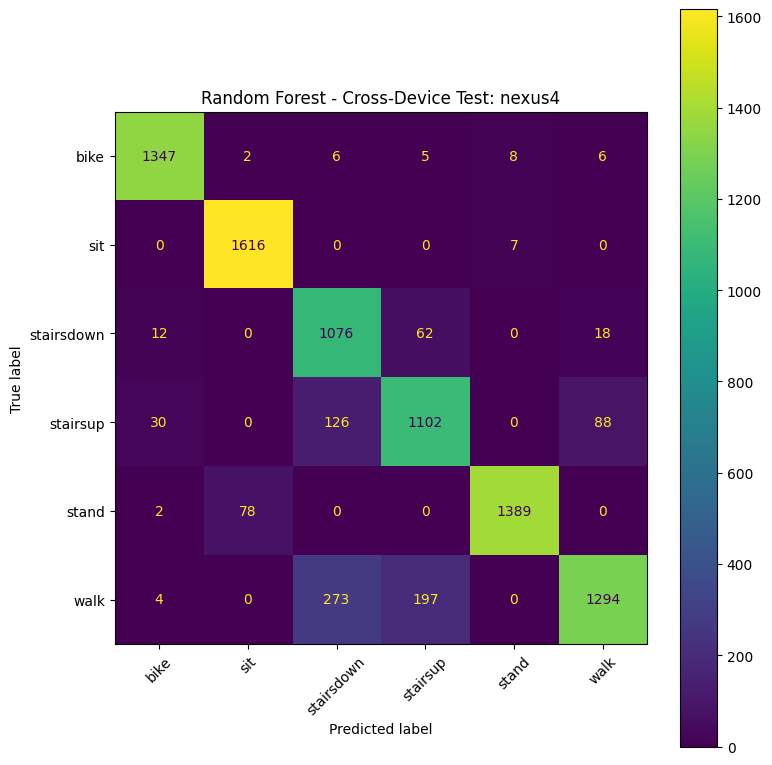

Generating confusion matrix for: s3


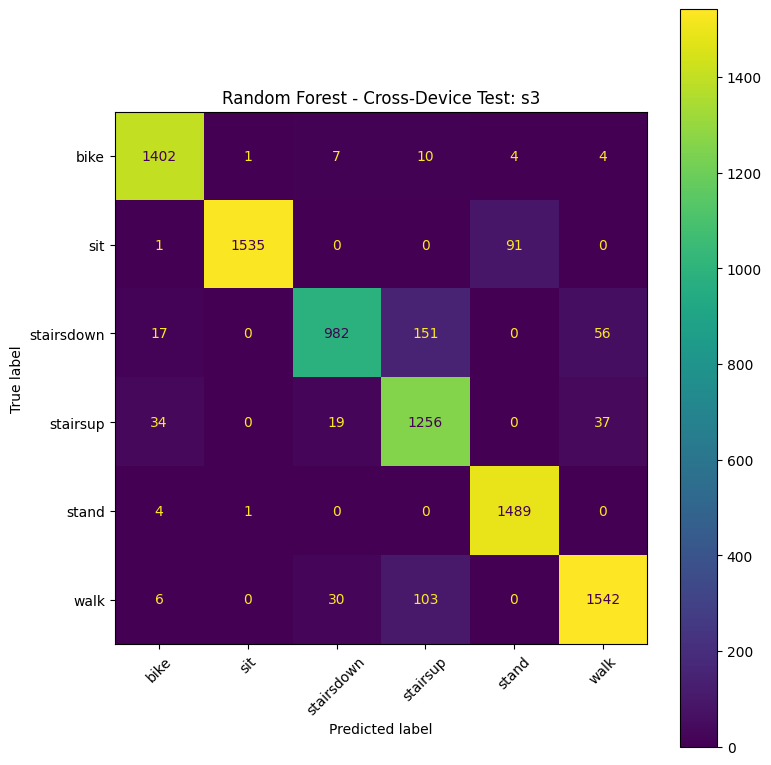

Generating confusion matrix for: s3mini


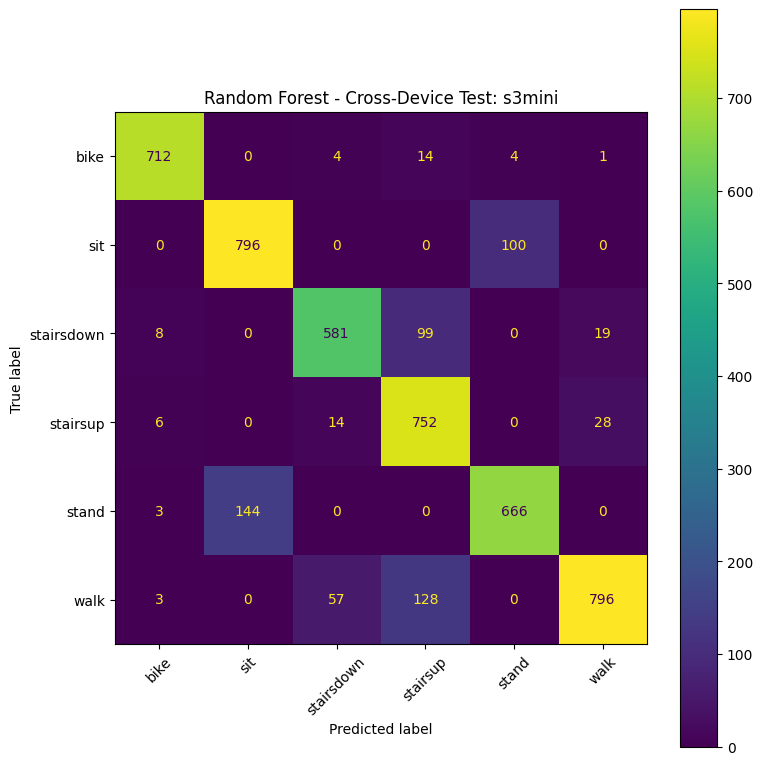

Generating confusion matrix for: samsungold


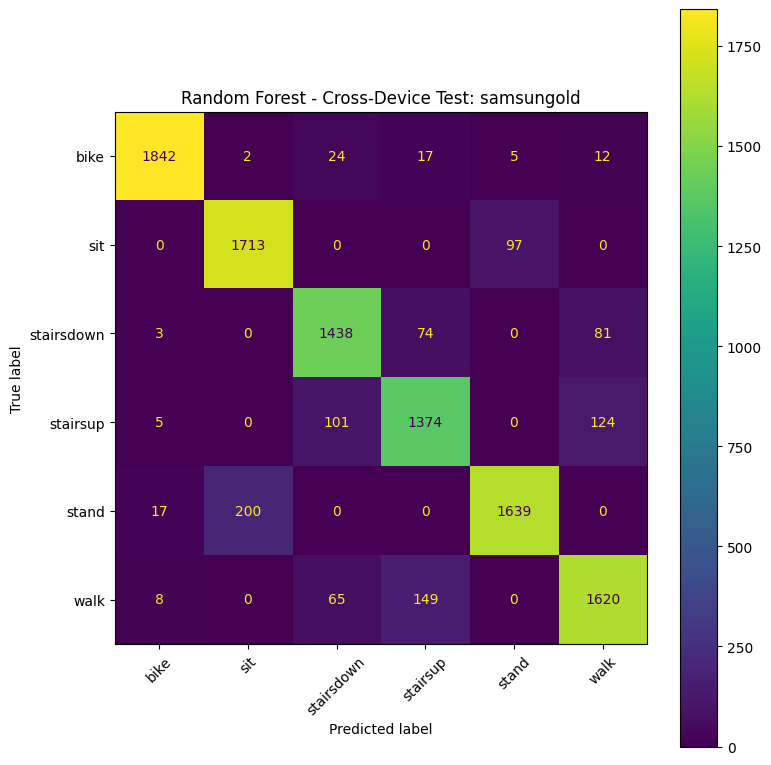

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

features_path = '/content/drive/MyDrive/ML_Project/hhar_features.parquet'

df = pl.read_parquet(features_path)

feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

target_column = 'Activity'

models = sorted(
    df.select('Model')
    .unique()
    .to_series()
    .to_list()
)

activity_labels = sorted(
    df.select('Activity')
    .unique()
    .to_series()
    .to_list()
)

for test_model in models:

    print(f"Generating confusion matrix for: {test_model}")

    train_df = df.filter(pl.col('Model') != test_model)
    test_df = df.filter(pl.col('Model') == test_model)

    X_train = train_df.select(feature_columns).to_pandas()
    y_train = train_df.select(target_column).to_pandas().squeeze()

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df.select(target_column).to_pandas().squeeze()

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=activity_labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=activity_labels
    )

    fig, ax = plt.subplots(figsize=(8, 8))

    disp.plot(
        ax=ax,
        xticks_rotation=45
    )

    ax.set_title(
        f'Random Forest - Cross-Device Test: {test_model}'
    )

    plt.tight_layout()
    plt.show()

In [ ]:
import polars as pl
import pandas as pd

from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

features_path = '/content/drive/MyDrive/ML_Project/hhar_features.parquet'

df = pl.read_parquet(features_path)

feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

target_column = 'Activity'

# Encode activity labels
label_encoder = LabelEncoder()

all_labels = (
    df
    .select(target_column)
    .to_series()
    .to_list()
)

label_encoder.fit(all_labels)

df = df.with_columns(
    pl.col(target_column)
    .map_elements(
        lambda x: int(label_encoder.transform([x])[0]),
        return_dtype=pl.Int32
    )
    .alias('Activity_Code')
)

models = sorted(
    df
    .select('Model')
    .unique()
    .to_series()
    .to_list()
)

results = []

for test_model in models:

    print(f"\nTesting on: {test_model}")

    # Split by device model
    train_df = df.filter(pl.col('Model') != test_model)
    test_df = df.filter(pl.col('Model') == test_model)

    X_train = train_df.select(feature_columns).to_pandas()
    y_train = train_df.select('Activity_Code').to_pandas().squeeze()

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df.select('Activity_Code').to_pandas().squeeze()

    # Build XGBoost classifier
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=len(label_encoder.classes_),
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    macro_precision = precision_score(
        y_test,
        y_pred,
        average='macro'
    )

    macro_recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    results.append({
        'Test_Model': test_model,
        'Train_Samples': len(X_train),
        'Test_Samples': len(X_test),
        'Accuracy': accuracy,
        'Macro_Precision': macro_precision,
        'Macro_Recall': macro_recall,
        'Macro_F1': macro_f1
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")

# Create results table
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("CROSS-DEVICE XGBOOST RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nAverage performance:")
print(
    results_df[
        ['Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1']
    ].mean().to_frame('Mean')
)

# Save results
results_path = '/content/drive/MyDrive/ML_Project/cross_device_xgb_results.csv'

results_df.to_csv(
    results_path,
    index=False
)

print("\nResults saved to:")
print(results_path)


Testing on: nexus4
Accuracy: 0.9031
Macro F1: 0.9010

Testing on: s3
Accuracy: 0.9389
Macro F1: 0.9349

Testing on: s3mini
Accuracy: 0.8788
Macro F1: 0.8805

Testing on: samsungold
Accuracy: 0.9116
Macro F1: 0.9101

CROSS-DEVICE XGBOOST RESULTS
Test_Model  Train_Samples  Test_Samples  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
    nexus4          24327          8748    0.9031           0.9016        0.9068    0.9010
        s3          24293          8782    0.9389           0.9395        0.9343    0.9349
    s3mini          28140          4935    0.8788           0.8861        0.8813    0.8805
samsungold          22465         10610    0.9116           0.9106        0.9102    0.9101

Average performance:
                     Mean
Accuracy         0.908083
Macro_Precision  0.909481
Macro_Recall     0.908161
Macro_F1         0.906608

Results saved to:
/content/drive/MyDrive/ML_Project/cross_device_xgb_results.csv


In [ ]:
import polars as pl
import pandas as pd

from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

features_path = '/content/drive/MyDrive/ML_Project/hhar_features.parquet'

df = pl.read_parquet(features_path)

feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

target_column = 'Activity'

# Encode activity labels
label_encoder = LabelEncoder()

all_labels = (
    df
    .select(target_column)
    .to_series()
    .to_list()
)

label_encoder.fit(all_labels)

df = df.with_columns(
    pl.col(target_column)
    .map_elements(
        lambda x: int(label_encoder.transform([x])[0]),
        return_dtype=pl.Int32
    )
    .alias('Activity_Code')
)

# Fixed user-level split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

models = sorted(
    df
    .select('Model')
    .unique()
    .to_series()
    .to_list()
)

results = []

for test_model in models:

    print(f"\nTesting on device model: {test_model}")

    # Select one device model
    model_df = df.filter(
        pl.col('Model') == test_model
    )

    # Split by user
    train_df = model_df.filter(
        pl.col('User').is_in(train_users)
    )

    test_df = model_df.filter(
        pl.col('User').is_in(test_users)
    )

    X_train = train_df.select(feature_columns).to_pandas()
    y_train = train_df.select('Activity_Code').to_pandas().squeeze()

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df.select('Activity_Code').to_pandas().squeeze()

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # Build XGBoost classifier
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=len(label_encoder.classes_),
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    macro_precision = precision_score(
        y_test,
        y_pred,
        average='macro'
    )

    macro_recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    results.append({
        'Model': test_model,
        'Train_Users': ','.join(train_users),
        'Test_Users': ','.join(test_users),
        'Train_Samples': len(X_train),
        'Test_Samples': len(X_test),
        'Accuracy': accuracy,
        'Macro_Precision': macro_precision,
        'Macro_Recall': macro_recall,
        'Macro_F1': macro_f1
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")

# Create results table
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("WITHIN-DEVICE XGBOOST RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nAverage performance:")

print(
    results_df[
        ['Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1']
    ].mean().to_frame('Mean')
)

# Save results
results_path = '/content/drive/MyDrive/ML_Project/within_device_xgb_results.csv'

results_df.to_csv(
    results_path,
    index=False
)

print("\nResults saved to:")
print(results_path)


Testing on device model: nexus4
Training samples: 6800
Test samples: 1948
Accuracy: 0.7433
Macro F1: 0.7176

Testing on device model: s3
Training samples: 6698
Test samples: 2084
Accuracy: 0.7318
Macro F1: 0.7143

Testing on device model: s3mini
Training samples: 3779
Test samples: 1156
Accuracy: 0.8192
Macro F1: 0.8088

Testing on device model: samsungold
Training samples: 8228
Test samples: 2382
Accuracy: 0.7145
Macro F1: 0.7085

WITHIN-DEVICE XGBOOST RESULTS
     Model   Train_Users Test_Users  Train_Samples  Test_Samples  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
    nexus4 a,b,c,d,e,f,g        h,i           6800          1948    0.7433           0.7982        0.7242    0.7176
        s3 a,b,c,d,e,f,g        h,i           6698          2084    0.7318           0.8055        0.7133    0.7143
    s3mini a,b,c,d,e,f,g        h,i           3779          1156    0.8192           0.8349        0.8135    0.8088
samsungold a,b,c,d,e,f,g        h,i           8228          2382    0

In [ ]:
import polars as pl
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier

# Load feature dataset
df = pl.read_parquet(
    "/content/drive/MyDrive/ML_Project/hhar_features.parquet"
)

# Define feature columns
feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

# Define fixed user split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

# Encode activity labels
label_encoder = LabelEncoder()
label_encoder.fit(df['Activity'].to_list())

df = df.with_columns(
    pl.col('Activity')
    .map_elements(
        lambda x: int(label_encoder.transform([x])[0]),
        return_dtype=pl.Int64
    )
    .alias('Activity_Encoded')
)

models = df['Model'].unique().sort().to_list()

results = []

for test_model in models:

    # Test data: target device and unseen users
    test_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(test_users))
    )

    # -------------------------
    # Within-device experiment
    # -------------------------

    within_train_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(train_users))
    )

    X_train = within_train_df.select(feature_columns).to_pandas()
    y_train = within_train_df['Activity_Encoded'].to_numpy()

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df['Activity_Encoded'].to_numpy()

    within_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=6,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    within_model.fit(X_train, y_train)

    y_pred = within_model.predict(X_test)

    results.append({
        'Test_Model': test_model,
        'Condition': 'Within-Device',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred, average='macro', zero_division=0
        )
    })

    # -------------------------
    # Cross-device experiment
    # -------------------------

    cross_train_df = df.filter(
        (pl.col('Model') != test_model) &
        (pl.col('User').is_in(train_users))
    )

    X_train = cross_train_df.select(feature_columns).to_pandas()
    y_train = cross_train_df['Activity_Encoded'].to_numpy()

    cross_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=6,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    cross_model.fit(X_train, y_train)

    y_pred = cross_model.predict(X_test)

    results.append({
        'Test_Model': test_model,
        'Condition': 'Cross-Device',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred, average='macro', zero_division=0
        )
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results
display(results_df.round(4))

# Save results
results_df.to_csv(
    "/content/drive/MyDrive/ML_Project/same_user_split_xgb_results.csv",
    index=False
)

print("Results saved successfully.")

,Test_Model,Condition,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,nexus4,Within-Device,0.7433,0.7982,0.7242,0.7176
1,nexus4,Cross-Device,0.7069,0.7828,0.6954,0.6894
2,s3,Within-Device,0.7318,0.8055,0.7133,0.7143
3,s3,Cross-Device,0.6646,0.7339,0.6574,0.6454
4,s3mini,Within-Device,0.8192,0.8349,0.8135,0.8088
5,s3mini,Cross-Device,0.7863,0.8232,0.7868,0.7660
6,samsungold,Within-Device,0.7145,0.7821,0.7121,0.7085
7,samsungold,Cross-Device,0.7779,0.8192,0.7761,0.7726


Results saved successfully.


In [ ]:
import polars as pl
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load feature dataset
df = pl.read_parquet(
    "/content/drive/MyDrive/ML_Project/hhar_features.parquet"
)

# Define feature columns
feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

# Define fixed user split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

# Define device models
models = df['Model'].unique().sort().to_list()

results = []

for test_model in models:

    # Test data
    test_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(test_users))
    )

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df['Activity'].to_numpy()

    # -------------------------
    # Within-device experiment
    # -------------------------

    within_train_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(train_users))
    )

    X_train = within_train_df.select(feature_columns).to_pandas()
    y_train = within_train_df['Activity'].to_numpy()

    within_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    within_model.fit(X_train, y_train)

    y_pred = within_model.predict(X_test)

    results.append({
        'Test_Model': test_model,
        'Condition': 'Within-Device',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred, average='macro', zero_division=0
        )
    })

    # -------------------------
    # Cross-device experiment
    # -------------------------

    cross_train_df = df.filter(
        (pl.col('Model') != test_model) &
        (pl.col('User').is_in(train_users))
    )

    X_train = cross_train_df.select(feature_columns).to_pandas()
    y_train = cross_train_df['Activity'].to_numpy()

    cross_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    cross_model.fit(X_train, y_train)

    y_pred = cross_model.predict(X_test)

    results.append({
        'Test_Model': test_model,
        'Condition': 'Cross-Device',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred, average='macro', zero_division=0
        )
    })

# Create results DataFrame
results_df = pd.DataFrame(results)

# Display results
display(results_df.round(4))

# Save results
results_df.to_csv(
    "/content/drive/MyDrive/ML_Project/same_user_split_rf_results.csv",
    index=False
)

print("Results saved successfully.")

,Test_Model,Condition,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,nexus4,Within-Device,0.7336,0.7806,0.7149,0.7095
1,nexus4,Cross-Device,0.7023,0.7690,0.6912,0.6871
2,s3,Within-Device,0.7159,0.7966,0.6952,0.6963
3,s3,Cross-Device,0.6612,0.7396,0.6495,0.6410
4,s3mini,Within-Device,0.7405,0.7807,0.7398,0.7289
5,s3mini,Cross-Device,0.7630,0.8083,0.7622,0.7468
6,samsungold,Within-Device,0.7322,0.7995,0.7280,0.7165
7,samsungold,Cross-Device,0.7250,0.7760,0.7216,0.7191


Results saved successfully.


In [ ]:
import polars as pl
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load feature dataset
df = pl.read_parquet(
    "/content/drive/MyDrive/ML_Project/hhar_features.parquet"
)

# Define feature columns
feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

# Define fixed user split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

# Define device models
models = df['Model'].unique().sort().to_list()

results = []

for test_model in models:

    # Test data
    test_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(test_users))
    )

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df['Activity'].to_numpy()

    # -------------------------
    # Within-device experiment
    # -------------------------

    within_train_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(train_users))
    )

    X_train = within_train_df.select(feature_columns).to_pandas()
    y_train = within_train_df['Activity'].to_numpy()

    within_model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])

    within_model.fit(X_train, y_train)

    y_pred = within_model.predict(X_test)

    results.append({
        'Test_Model': test_model,
        'Condition': 'Within-Device',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred, average='macro', zero_division=0
        )
    })

    # -------------------------
    # Cross-device experiment
    # -------------------------

    cross_train_df = df.filter(
        (pl.col('Model') != test_model) &
        (pl.col('User').is_in(train_users))
    )

    X_train = cross_train_df.select(feature_columns).to_pandas()
    y_train = cross_train_df['Activity'].to_numpy()

    cross_model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])

    cross_model.fit(X_train, y_train)

    y_pred = cross_model.predict(X_test)

    results.append({
        'Test_Model': test_model,
        'Condition': 'Cross-Device',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred, average='macro', zero_division=0
        )
    })

# Create results DataFrame
results_df = pd.DataFrame(results)

# Display results
display(results_df.round(4))

# Save results
results_df.to_csv(
    "/content/drive/MyDrive/ML_Project/same_user_split_lr_results.csv",
    index=False
)

print("Results saved successfully.")

,Test_Model,Condition,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,nexus4,Within-Device,0.6663,0.7192,0.6550,0.6486
1,nexus4,Cross-Device,0.7274,0.7578,0.7258,0.7175
2,s3,Within-Device,0.7135,0.7513,0.7040,0.7013
3,s3,Cross-Device,0.7807,0.8216,0.7722,0.7757
4,s3mini,Within-Device,0.8080,0.8322,0.8127,0.8062
5,s3mini,Cross-Device,0.7785,0.8158,0.7776,0.7744
6,samsungold,Within-Device,0.7926,0.8155,0.7870,0.7863
7,samsungold,Cross-Device,0.7422,0.7664,0.7373,0.7353


Results saved successfully.


In [ ]:
import pandas as pd

# Load experiment results
xgb_results = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/same_user_split_xgb_results.csv"
)

rf_results = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/same_user_split_rf_results.csv"
)

lr_results = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/same_user_split_lr_results.csv"
)

# Add model names
xgb_results['Model'] = 'XGBoost'
rf_results['Model'] = 'Random Forest'
lr_results['Model'] = 'Logistic Regression'

# Combine all results
all_results = pd.concat(
    [xgb_results, rf_results, lr_results],
    ignore_index=True
)

# Reorder columns
all_results = all_results[
    [
        'Model',
        'Test_Model',
        'Condition',
        'Accuracy',
        'Macro_Precision',
        'Macro_Recall',
        'Macro_F1'
    ]
]

# Calculate Cross-Device change relative to Within-Device
comparison = all_results.pivot_table(
    index=['Model', 'Test_Model'],
    columns='Condition',
    values='Macro_F1'
).reset_index()

comparison['F1_Change_pp'] = (
    comparison['Cross-Device'] -
    comparison['Within-Device']
) * 100

# Display complete results
print("Complete Results")
display(all_results.round(4))

# Display comparison
print("Within-Device vs Cross-Device Macro-F1")
display(comparison.round(2))

# Calculate model-level averages
model_summary = all_results.groupby(
    ['Model', 'Condition']
)[
    ['Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1']
].mean().reset_index()

print("Model-Level Average Results")
display(model_summary.round(4))

# Save combined results
all_results.to_csv(
    "/content/drive/MyDrive/ML_Project/all_model_results.csv",
    index=False
)

comparison.to_csv(
    "/content/drive/MyDrive/ML_Project/within_cross_f1_comparison.csv",
    index=False
)

model_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/model_summary_results.csv",
    index=False
)

print("All result files saved successfully.")

Complete Results


,Model,Test_Model,Condition,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,XGBoost,nexus4,Within-Device,0.7433,0.7982,0.7242,0.7176
1,XGBoost,nexus4,Cross-Device,0.7069,0.7828,0.6954,0.6894
2,XGBoost,s3,Within-Device,0.7318,0.8055,0.7133,0.7143
3,XGBoost,s3,Cross-Device,0.6646,0.7339,0.6574,0.6454
4,XGBoost,s3mini,Within-Device,0.8192,0.8349,0.8135,0.8088
5,XGBoost,s3mini,Cross-Device,0.7863,0.8232,0.7868,0.7660
6,XGBoost,samsungold,Within-Device,0.7145,0.7821,0.7121,0.7085
7,XGBoost,samsungold,Cross-Device,0.7779,0.8192,0.7761,0.7726
8,Random Forest,nexus4,Within-Device,0.7336,0.7806,0.7149,0.7095
9,Random Forest,nexus4,Cross-Device,0.7023,0.7690,0.6912,0.6871


Within-Device vs Cross-Device Macro-F1


Condition,Model,Test_Model,Cross-Device,Within-Device,F1_Change_pp
0,Logistic Regression,nexus4,0.72,0.65,6.89
1,Logistic Regression,s3,0.78,0.70,7.44
2,Logistic Regression,s3mini,0.77,0.81,-3.18
3,Logistic Regression,samsungold,0.74,0.79,-5.10
4,Random Forest,nexus4,0.69,0.71,-2.23
5,Random Forest,s3,0.64,0.70,-5.53
6,Random Forest,s3mini,0.75,0.73,1.79
7,Random Forest,samsungold,0.72,0.72,0.25
8,XGBoost,nexus4,0.69,0.72,-2.81
9,XGBoost,s3,0.65,0.71,-6.89


Model-Level Average Results


,Model,Condition,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,Logistic Regression,Cross-Device,0.7572,0.7904,0.7532,0.7507
1,Logistic Regression,Within-Device,0.7451,0.7796,0.7397,0.7356
2,Random Forest,Cross-Device,0.7129,0.7732,0.7061,0.6985
3,Random Forest,Within-Device,0.7305,0.7893,0.7195,0.7128
4,XGBoost,Cross-Device,0.7339,0.7898,0.7289,0.7183
5,XGBoost,Within-Device,0.7522,0.8052,0.7408,0.7373


All result files saved successfully.


In [ ]:
import polars as pl
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier

# Load feature dataset
df = pl.read_parquet(
    "/content/drive/MyDrive/ML_Project/hhar_features.parquet"
)

# Define feature columns
feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

# Define fixed user split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

# Encode activity labels
label_encoder = LabelEncoder()
label_encoder.fit(df['Activity'].to_list())

df = df.with_columns(
    pl.col('Activity')
    .map_elements(
        lambda x: int(label_encoder.transform([x])[0]),
        return_dtype=pl.Int64
    )
    .alias('Activity_Encoded')
)

models = df['Model'].unique().sort().to_list()

results = []

for test_model in models:

    # Test data
    test_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(test_users))
    )

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df['Activity_Encoded'].to_numpy()

    # --------------------------------
    # Within-device training data
    # --------------------------------

    within_train_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(train_users))
    )

    # Count samples per activity
    activity_counts = (
        within_train_df
        .group_by('Activity_Encoded')
        .len()
        .sort('Activity_Encoded')
    )

    # --------------------------------
    # Cross-device training data
    # --------------------------------

    cross_train_df = df.filter(
        (pl.col('Model') != test_model) &
        (pl.col('User').is_in(train_users))
    )

    # Balance cross-device data to match
    # the within-device class distribution
    balanced_parts = []

    for row in activity_counts.iter_rows():
        activity = row[0]
        target_count = row[1]

        activity_df = cross_train_df.filter(
            pl.col('Activity_Encoded') == activity
        )

        # Use deterministic sampling
        sampled_df = activity_df.sample(
            n=target_count,
            seed=42
        )

        balanced_parts.append(sampled_df)

    balanced_cross_train_df = pl.concat(balanced_parts)

    # --------------------------------
    # Verify training sizes
    # --------------------------------

    within_size = within_train_df.height
    cross_size = balanced_cross_train_df.height

    print(
        f"{test_model}: "
        f"Within={within_size}, "
        f"Cross={cross_size}"
    )

    # --------------------------------
    # Within-device XGBoost
    # --------------------------------

    X_train = within_train_df.select(
        feature_columns
    ).to_pandas()

    y_train = within_train_df[
        'Activity_Encoded'
    ].to_numpy()

    within_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=6,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    within_model.fit(X_train, y_train)

    y_pred = within_model.predict(X_test)

    results.append({
        'Test_Model': test_model,
        'Condition': 'Within-Device',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        )
    })

    # --------------------------------
    # Balanced cross-device XGBoost
    # --------------------------------

    X_train = balanced_cross_train_df.select(
        feature_columns
    ).to_pandas()

    y_train = balanced_cross_train_df[
        'Activity_Encoded'
    ].to_numpy()

    cross_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=6,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    cross_model.fit(X_train, y_train)

    y_pred = cross_model.predict(X_test)

    results.append({
        'Test_Model': test_model,
        'Condition': 'Cross-Device-Balanced',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        )
    })

# Create results DataFrame
results_df = pd.DataFrame(results)

print("\nBalanced XGBoost Results")
display(results_df.round(4))

# Save results
results_df.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "balanced_xgb_results.csv",
    index=False
)

print("Results saved successfully.")

nexus4: Within=6800, Cross=6800
s3: Within=6698, Cross=6698
s3mini: Within=3779, Cross=3779
samsungold: Within=8228, Cross=8228

Balanced XGBoost Results


,Test_Model,Condition,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,nexus4,Within-Device,0.7433,0.7982,0.7242,0.7176
1,nexus4,Cross-Device-Balanced,0.7017,0.7747,0.6889,0.6857
2,s3,Within-Device,0.7318,0.8055,0.7133,0.7143
3,s3,Cross-Device-Balanced,0.6137,0.7027,0.6036,0.5841
4,s3mini,Within-Device,0.8192,0.8349,0.8135,0.8088
5,s3mini,Cross-Device-Balanced,0.7474,0.8071,0.7462,0.7262
6,samsungold,Within-Device,0.7145,0.7821,0.7121,0.7085
7,samsungold,Cross-Device-Balanced,0.7494,0.7981,0.7463,0.7442


Results saved successfully.


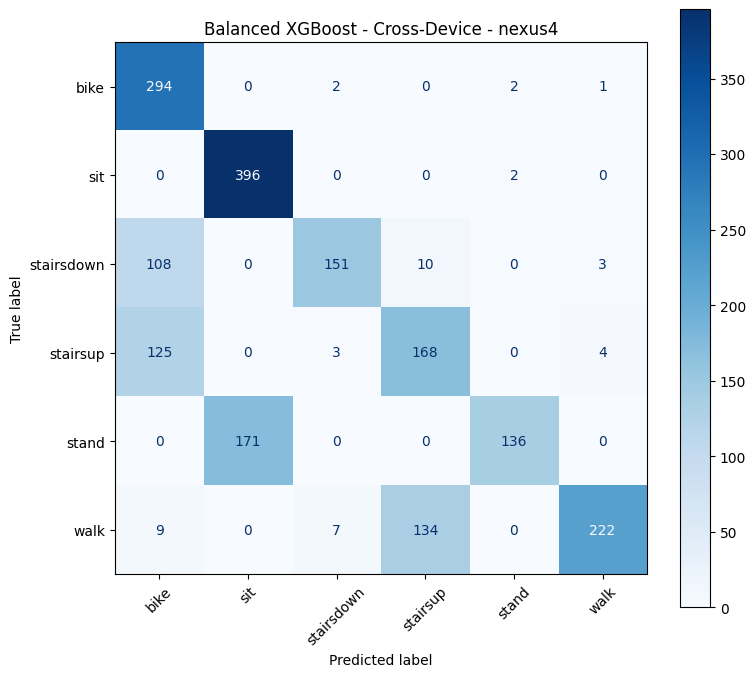

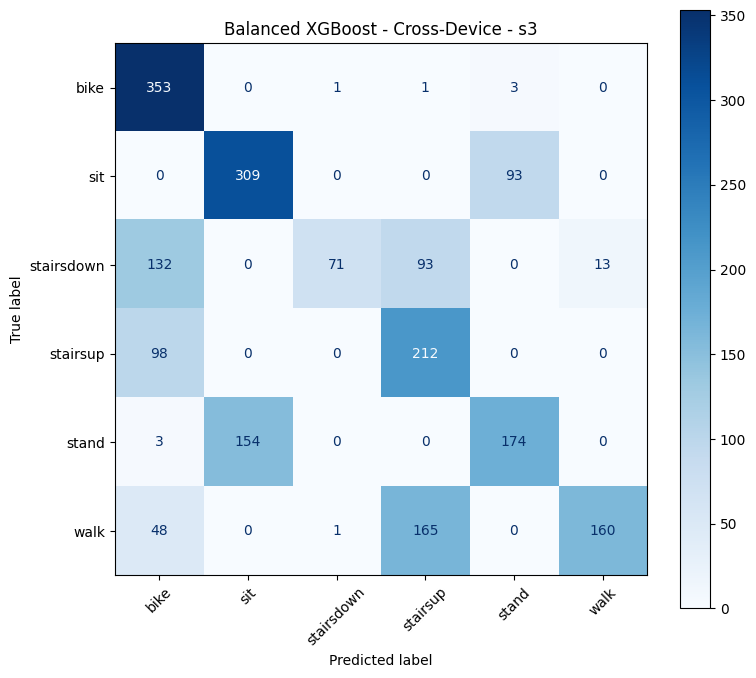

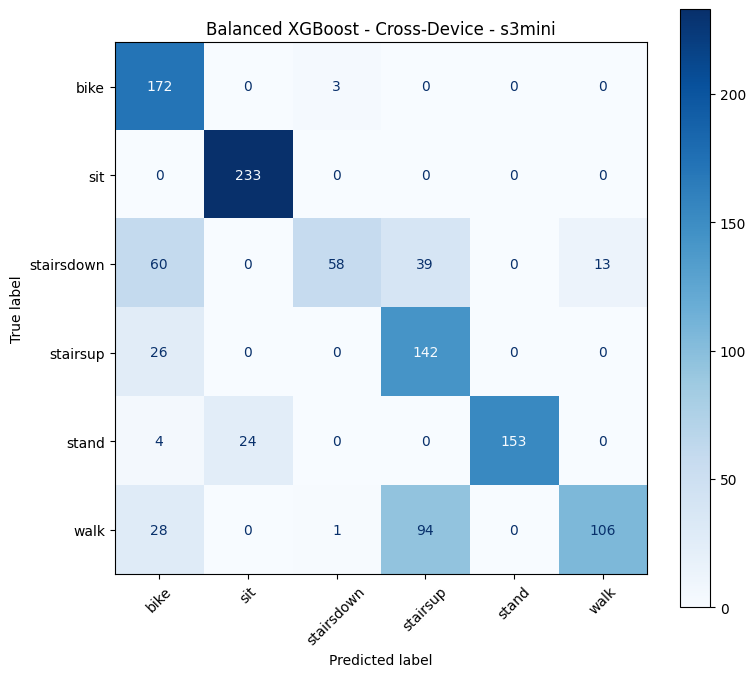

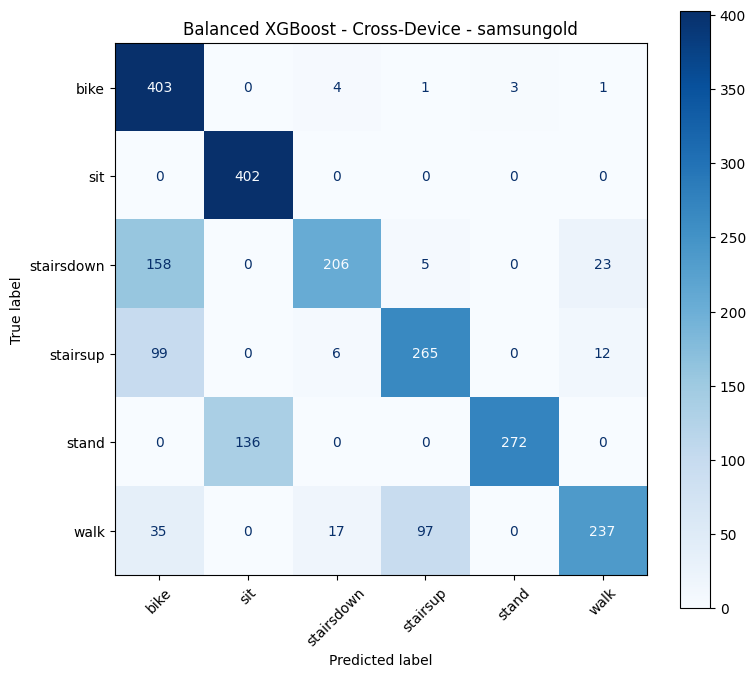

In [ ]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# Load feature dataset
df = pl.read_parquet(
    "/content/drive/MyDrive/ML_Project/hhar_features.parquet"
)

# Define feature columns
feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

# Define fixed user split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

# Encode activity labels
label_encoder = LabelEncoder()
label_encoder.fit(df['Activity'].to_list())

df = df.with_columns(
    pl.col('Activity')
    .map_elements(
        lambda x: int(label_encoder.transform([x])[0]),
        return_dtype=pl.Int64
    )
    .alias('Activity_Encoded')
)

models = df['Model'].unique().sort().to_list()

for test_model in models:

    # Test data
    test_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(test_users))
    )

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df['Activity_Encoded'].to_numpy()

    # Within-device training data
    within_train_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(train_users))
    )

    # Get class counts from within-device training data
    activity_counts = (
        within_train_df
        .group_by('Activity_Encoded')
        .len()
        .sort('Activity_Encoded')
    )

    # Cross-device training data
    cross_train_df = df.filter(
        (pl.col('Model') != test_model) &
        (pl.col('User').is_in(train_users))
    )

    # Balance cross-device training data
    balanced_parts = []

    for row in activity_counts.iter_rows():
        activity = row[0]
        target_count = row[1]

        activity_df = cross_train_df.filter(
            pl.col('Activity_Encoded') == activity
        )

        sampled_df = activity_df.sample(
            n=target_count,
            seed=42
        )

        balanced_parts.append(sampled_df)

    balanced_cross_train_df = pl.concat(balanced_parts)

    # Prepare training data
    X_train = balanced_cross_train_df.select(
        feature_columns
    ).to_pandas()

    y_train = balanced_cross_train_df[
        'Activity_Encoded'
    ].to_numpy()

    # Train XGBoost
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=6,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=range(len(label_encoder.classes_))
    )

    # Plot
    fig, ax = plt.subplots(figsize=(8, 7))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    display.plot(
        ax=ax,
        xticks_rotation=45,
        cmap='Blues'
    )

    ax.set_title(
        f'Balanced XGBoost - Cross-Device - {test_model}'
    )

    plt.tight_layout()
    plt.show()

In [ ]:
import polars as pl
import pandas as pd
import IPython.display as ipyd

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load feature dataset
df = pl.read_parquet(
    "/content/drive/MyDrive/ML_Project/hhar_features.parquet"
)

# Define feature columns
feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

# Define fixed user split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

# Define device models
models = df['Model'].unique().sort().to_list()

rf_results = []

for test_model in models:

    # Test data
    test_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(test_users))
    )

    X_test = test_df.select(feature_columns).to_pandas()
    y_test = test_df['Activity'].to_numpy()

    # --------------------------------
    # Within-device training data
    # --------------------------------

    within_train_df = df.filter(
        (pl.col('Model') == test_model) &
        (pl.col('User').is_in(train_users))
    )

    # Get class counts from within-device data
    activity_counts = (
        within_train_df
        .group_by('Activity')
        .len()
        .sort('Activity')
    )

    # --------------------------------
    # Cross-device training data
    # --------------------------------

    cross_train_df = df.filter(
        (pl.col('Model') != test_model) &
        (pl.col('User').is_in(train_users))
    )

    # Balance cross-device data
    balanced_parts = []

    for row in activity_counts.iter_rows():
        activity = row[0]
        target_count = row[1]

        activity_df = cross_train_df.filter(
            pl.col('Activity') == activity
        )

        sampled_df = activity_df.sample(
            n=target_count,
            seed=42
        )

        balanced_parts.append(sampled_df)

    balanced_cross_train_df = pl.concat(balanced_parts)

    # Prepare Within-Device data
    X_within = within_train_df.select(
        feature_columns
    ).to_pandas()

    y_within = within_train_df['Activity'].to_numpy()

    # Prepare Cross-Device data
    X_cross = balanced_cross_train_df.select(
        feature_columns
    ).to_pandas()

    y_cross = balanced_cross_train_df['Activity'].to_numpy()

    # --------------------------------
    # Random Forest - Within-Device
    # --------------------------------

    rf_within = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf_within.fit(X_within, y_within)

    y_pred = rf_within.predict(X_test)

    rf_results.append({
        'Test_Model': test_model,
        'Condition': 'Within-Device',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        )
    })

    # --------------------------------
    # Random Forest - Cross-Device
    # --------------------------------

    rf_cross = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf_cross.fit(X_cross, y_cross)

    y_pred = rf_cross.predict(X_test)

    rf_results.append({
        'Test_Model': test_model,
        'Condition': 'Cross-Device-Balanced',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        )
    })

    # --------------------------------
    # Logistic Regression - Within
    # --------------------------------

    lr_within = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])

    lr_within.fit(X_within, y_within)

    y_pred = lr_within.predict(X_test)

    lr_results.append({
        'Test_Model': test_model,
        'Condition': 'Within-Device',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        )
    })

    # --------------------------------
    # Logistic Regression - Cross
    # --------------------------------

    lr_cross = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])

    lr_cross.fit(X_cross, y_cross)

    y_pred = lr_cross.predict(X_test)

    lr_results.append({
        'Test_Model': test_model,
        'Condition': 'Cross-Device-Balanced',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        ),
        'Macro_F1': f1_score(
            y_test, y_pred,
            average='macro',
            zero_division=0
        )
    })

# Convert results to DataFrames
rf_results_df = pd.DataFrame(rf_results)
lr_results_df = pd.DataFrame(lr_results)

# Display results using safe IPython display
print("Balanced Random Forest Results")
ipyd.display(rf_results_df.round(4))

print("Balanced Logistic Regression Results")
ipyd.display(lr_results_df.round(4))

# Save results
rf_results_df.to_csv(
    "/content/drive/MyDrive/ML_Project/balanced_rf_results.csv",
    index=False
)

lr_results_df.to_csv(
    "/content/drive/MyDrive/ML_Project/balanced_lr_results.csv",
    index=False
)

print("Results saved successfully.")

Balanced Random Forest Results


,Test_Model,Condition,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,nexus4,Within-Device,0.7336,0.7806,0.7149,0.7095
1,nexus4,Cross-Device-Balanced,0.7017,0.7703,0.6921,0.6880
2,s3,Within-Device,0.7159,0.7966,0.6952,0.6963
3,s3,Cross-Device-Balanced,0.6483,0.7492,0.6340,0.6246
4,s3mini,Within-Device,0.7405,0.7807,0.7398,0.7289
5,s3mini,Cross-Device-Balanced,0.7249,0.7991,0.7228,0.7110
6,samsungold,Within-Device,0.7322,0.7995,0.7280,0.7165
7,samsungold,Cross-Device-Balanced,0.7007,0.7556,0.6964,0.6942


Balanced Logistic Regression Results


,Test_Model,Condition,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,nexus4,Within-Device,0.6663,0.7192,0.6550,0.6486
1,nexus4,Cross-Device-Balanced,0.7254,0.7607,0.7218,0.7157
2,s3,Within-Device,0.7135,0.7513,0.7040,0.7013
3,s3,Cross-Device-Balanced,0.7716,0.8138,0.7621,0.7660
4,s3mini,Within-Device,0.8080,0.8322,0.8127,0.8062
5,s3mini,Cross-Device-Balanced,0.7889,0.8180,0.7885,0.7848
6,samsungold,Within-Device,0.7926,0.8155,0.7870,0.7863
7,samsungold,Cross-Device-Balanced,0.7515,0.7776,0.7466,0.7448
8,nexus4,Within-Device,0.6663,0.7192,0.6550,0.6486
9,nexus4,Cross-Device-Balanced,0.7254,0.7607,0.7218,0.7157


Results saved successfully.


In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import IPython.display as ipyd

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier

# Load feature dataset
df = pl.read_parquet(
    "/content/drive/MyDrive/ML_Project/hhar_features.parquet"
)

# Define feature columns
feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

# Define fixed user split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

# Encode activity labels
label_encoder = LabelEncoder()
label_encoder.fit(df['Activity'].to_list())

df = df.with_columns(
    pl.col('Activity')
    .map_elements(
        lambda x: int(label_encoder.transform([x])[0]),
        return_dtype=pl.Int64
    )
    .alias('Activity_Encoded')
)

models = df['Model'].unique().sort().to_list()

# Sampling seeds
seeds = [42, 123, 2024, 7, 99]

results = []

for seed in seeds:

    for test_model in models:

        # Test data
        test_df = df.filter(
            (pl.col('Model') == test_model) &
            (pl.col('User').is_in(test_users))
        )

        X_test = test_df.select(feature_columns).to_pandas()
        y_test = test_df['Activity_Encoded'].to_numpy()

        # Within-device training data
        within_train_df = df.filter(
            (pl.col('Model') == test_model) &
            (pl.col('User').is_in(train_users))
        )

        # Get within-device class counts
        activity_counts = (
            within_train_df
            .group_by('Activity_Encoded')
            .len()
            .sort('Activity_Encoded')
        )

        # Cross-device training data
        cross_train_df = df.filter(
            (pl.col('Model') != test_model) &
            (pl.col('User').is_in(train_users))
        )

        # Balance cross-device data
        balanced_parts = []

        for row in activity_counts.iter_rows():
            activity = row[0]
            target_count = row[1]

            activity_df = cross_train_df.filter(
                pl.col('Activity_Encoded') == activity
            )

            sampled_df = activity_df.sample(
                n=target_count,
                seed=seed
            )

            balanced_parts.append(sampled_df)

        balanced_cross_train_df = pl.concat(
            balanced_parts
        )

        # Prepare training data
        X_train = balanced_cross_train_df.select(
            feature_columns
        ).to_pandas()

        y_train = balanced_cross_train_df[
            'Activity_Encoded'
        ].to_numpy()

        # Train XGBoost
        model = XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softmax',
            num_class=6,
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Store results
        results.append({
            'Seed': seed,
            'Test_Model': test_model,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Macro_Precision': precision_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            ),
            'Macro_Recall': recall_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            ),
            'Macro_F1': f1_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )
        })

# Convert to DataFrame
multi_seed_results = pd.DataFrame(results)

# Display all results using safe IPython display
print("XGBoost Cross-Device Results by Seed")
ipyd.display(
    multi_seed_results.round(4)
)

# Calculate mean and standard deviation by device
device_summary = (
    multi_seed_results
    .groupby('Test_Model')
    [
        [
            'Accuracy',
            'Macro_Precision',
            'Macro_Recall',
            'Macro_F1'
        ]
    ]
    .agg(['mean', 'std'])
)

print("Mean and Standard Deviation by Device")
ipyd.display(
    device_summary.round(4)
)

# Calculate overall mean and standard deviation
overall_summary = (
    multi_seed_results
    [
        [
            'Accuracy',
            'Macro_Precision',
            'Macro_Recall',
            'Macro_F1'
        ]
    ]
    .agg(['mean', 'std'])
)

print("Overall Mean and Standard Deviation")
ipyd.display(
    overall_summary.round(4)
)

# Save results
multi_seed_results.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "xgb_cross_device_multi_seed_results.csv",
    index=False
)

device_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "xgb_cross_device_device_summary.csv"
)

overall_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "xgb_cross_device_overall_summary.csv"
)

print("Results saved successfully.")

XGBoost Cross-Device Results by Seed


,Seed,Test_Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,42,nexus4,0.7017,0.7747,0.6889,0.6857
1,42,s3,0.6137,0.7027,0.6036,0.5841
2,42,s3mini,0.7474,0.8071,0.7462,0.7262
3,42,samsungold,0.7494,0.7981,0.7463,0.7442
4,123,nexus4,0.7053,0.7579,0.6963,0.6920
5,123,s3,0.6478,0.7263,0.6374,0.6286
6,123,s3mini,0.7829,0.8225,0.7840,0.7675
7,123,samsungold,0.7531,0.8052,0.7506,0.7470
8,2024,nexus4,0.6982,0.7625,0.6865,0.6798
9,2024,s3,0.6593,0.7365,0.6519,0.6419


Mean and Standard Deviation by Device


Accuracy         Macro_Precision         Macro_Recall          \
               mean     std            mean     std         mean     std   
Test_Model                                                                 
nexus4       0.7020  0.0031          0.7630  0.0068       0.6914  0.0042   
s3           0.6496  0.0211          0.7281  0.0151       0.6407  0.0220   
s3mini       0.7664  0.0152          0.8163  0.0080       0.7676  0.0165   
samsungold   0.7520  0.0092          0.8008  0.0073       0.7493  0.0095   

           Macro_F1          
               mean     std  
Test_Model                   
nexus4       0.6868  0.0050  
s3           0.6297  0.0266  
s3mini       0.7481  0.0179  
samsungold   0.7467  0.0095

Overall Mean and Standard Deviation


,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
mean,0.7175,0.7770,0.7123,0.7028
std,0.0488,0.0363,0.0531,0.0525


Results saved successfully.


In [ ]:
import polars as pl
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load feature dataset
df = pl.read_parquet(
    "/content/drive/MyDrive/ML_Project/hhar_features.parquet"
)

# Define feature columns
feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

# Define fixed user split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

# Define sampling seeds
seeds = [42, 123, 2024, 7, 99]

# Define device models
models = df['Model'].unique().sort().to_list()

results = []

for seed in seeds:

    for test_model in models:

        # Test data
        test_df = df.filter(
            (pl.col('Model') == test_model) &
            (pl.col('User').is_in(test_users))
        )

        X_test = test_df.select(
            feature_columns
        ).to_pandas()

        y_test = test_df['Activity'].to_numpy()

        # --------------------------------
        # Within-device training data
        # --------------------------------

        within_train_df = df.filter(
            (pl.col('Model') == test_model) &
            (pl.col('User').is_in(train_users))
        )

        # Get class counts from within-device data
        activity_counts = (
            within_train_df
            .group_by('Activity')
            .len()
            .sort('Activity')
        )

        # --------------------------------
        # Cross-device training data
        # --------------------------------

        cross_train_df = df.filter(
            (pl.col('Model') != test_model) &
            (pl.col('User').is_in(train_users))
        )

        # Balance cross-device data
        balanced_parts = []

        for row in activity_counts.iter_rows():

            activity = row[0]
            target_count = row[1]

            activity_df = cross_train_df.filter(
                pl.col('Activity') == activity
            )

            sampled_df = activity_df.sample(
                n=target_count,
                seed=seed
            )

            balanced_parts.append(sampled_df)

        balanced_cross_train_df = pl.concat(
            balanced_parts
        )

        # Prepare cross-device training data
        X_train = balanced_cross_train_df.select(
            feature_columns
        ).to_pandas()

        y_train = balanced_cross_train_df[
            'Activity'
        ].to_numpy()

        # --------------------------------
        # Train Random Forest
        # --------------------------------

        model = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Store results
        results.append({
            'Seed': seed,
            'Test_Model': test_model,
            'Accuracy': accuracy_score(
                y_test, y_pred
            ),
            'Macro_Precision': precision_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            ),
            'Macro_Recall': recall_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            ),
            'Macro_F1': f1_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )
        })

# Convert results to DataFrame
rf_multi_seed_results = pd.DataFrame(results)

print("Random Forest Cross-Device Results by Seed")

ipyd.display(
    rf_multi_seed_results.round(4)
)

# --------------------------------
# Device-level summary
# --------------------------------

rf_device_summary = (
    rf_multi_seed_results
    .groupby('Test_Model')
    [
        [
            'Accuracy',
            'Macro_Precision',
            'Macro_Recall',
            'Macro_F1'
        ]
    ]
    .agg(['mean', 'std'])
)

print("Mean and Standard Deviation by Device")

ipyd.display(
    rf_device_summary.round(4)
)

# --------------------------------
# Overall summary
# --------------------------------

rf_overall_summary = (
    rf_multi_seed_results
    [
        [
            'Accuracy',
            'Macro_Precision',
            'Macro_Recall',
            'Macro_F1'
        ]
    ]
    .agg(['mean', 'std'])
)

print("Overall Mean and Standard Deviation")

ipyd.display(
    rf_overall_summary.round(4)
)

# Save results
rf_multi_seed_results.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "rf_cross_device_multi_seed_results.csv",
    index=False
)

rf_device_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "rf_cross_device_device_summary.csv"
)

rf_overall_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "rf_cross_device_overall_summary.csv"
)

print("Results saved successfully.")

Random Forest Cross-Device Results by Seed


,Seed,Test_Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,42,nexus4,0.7017,0.7703,0.6921,0.6880
1,42,s3,0.6483,0.7492,0.6340,0.6246
2,42,s3mini,0.7249,0.7991,0.7228,0.7110
3,42,samsungold,0.7007,0.7556,0.6964,0.6942
4,123,nexus4,0.7038,0.7720,0.6941,0.6899
5,123,s3,0.6555,0.7439,0.6415,0.6359
6,123,s3mini,0.7535,0.7941,0.7534,0.7379
7,123,samsungold,0.7107,0.7647,0.7067,0.7040
8,2024,nexus4,0.6961,0.7685,0.6847,0.6799
9,2024,s3,0.6603,0.7528,0.6473,0.6401


Mean and Standard Deviation by Device


Accuracy         Macro_Precision         Macro_Recall          \
               mean     std            mean     std         mean     std   
Test_Model                                                                 
nexus4       0.7003  0.0030          0.7719  0.0026       0.6898  0.0037   
s3           0.6563  0.0057          0.7498  0.0051       0.6428  0.0058   
s3mini       0.7443  0.0170          0.7982  0.0050       0.7424  0.0173   
samsungold   0.7062  0.0051          0.7613  0.0046       0.7022  0.0053   

           Macro_F1          
               mean     std  
Test_Model                   
nexus4       0.6854  0.0039  
s3           0.6353  0.0080  
s3mini       0.7290  0.0175  
samsungold   0.6991  0.0053

Overall Mean and Standard Deviation


,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
mean,0.7018,0.7703,0.6943,0.6872
std,0.0332,0.0188,0.0375,0.0360


Results saved successfully.


In [ ]:
import polars as pl
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load feature dataset
df = pl.read_parquet(
    "/content/drive/MyDrive/ML_Project/hhar_features.parquet"
)

# Define feature columns
feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

# Define fixed user split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

# Define sampling seeds
seeds = [42, 123, 2024, 7, 99]

# Define device models
models = df['Model'].unique().sort().to_list()

results = []

for seed in seeds:

    for test_model in models:

        # Test data
        test_df = df.filter(
            (pl.col('Model') == test_model) &
            (pl.col('User').is_in(test_users))
        )

        X_test = test_df.select(
            feature_columns
        ).to_pandas()

        y_test = test_df['Activity'].to_numpy()

        # --------------------------------
        # Within-device training data
        # --------------------------------

        within_train_df = df.filter(
            (pl.col('Model') == test_model) &
            (pl.col('User').is_in(train_users))
        )

        # Get class counts from within-device data
        activity_counts = (
            within_train_df
            .group_by('Activity')
            .len()
            .sort('Activity')
        )

        # --------------------------------
        # Cross-device training data
        # --------------------------------

        cross_train_df = df.filter(
            (pl.col('Model') != test_model) &
            (pl.col('User').is_in(train_users))
        )

        # Balance cross-device data
        balanced_parts = []

        for row in activity_counts.iter_rows():

            activity = row[0]
            target_count = row[1]

            activity_df = cross_train_df.filter(
                pl.col('Activity') == activity
            )

            sampled_df = activity_df.sample(
                n=target_count,
                seed=seed
            )

            balanced_parts.append(sampled_df)

        balanced_cross_train_df = pl.concat(
            balanced_parts
        )

        # Prepare training data
        X_train = balanced_cross_train_df.select(
            feature_columns
        ).to_pandas()

        y_train = balanced_cross_train_df[
            'Activity'
        ].to_numpy()

        # --------------------------------
        # Train Logistic Regression
        # --------------------------------

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(
                max_iter=1000,
                random_state=42
            ))
        ])

        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Store results
        results.append({
            'Seed': seed,
            'Test_Model': test_model,
            'Accuracy': accuracy_score(
                y_test,
                y_pred
            ),
            'Macro_Precision': precision_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            ),
            'Macro_Recall': recall_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            ),
            'Macro_F1': f1_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )
        })

# Convert results to DataFrame
lr_multi_seed_results = pd.DataFrame(results)

print("Logistic Regression Cross-Device Results by Seed")

ipyd.display(
    lr_multi_seed_results.round(4)
)

# --------------------------------
# Device-level summary
# --------------------------------

lr_device_summary = (
    lr_multi_seed_results
    .groupby('Test_Model')
    [
        [
            'Accuracy',
            'Macro_Precision',
            'Macro_Recall',
            'Macro_F1'
        ]
    ]
    .agg(['mean', 'std'])
)

print("Mean and Standard Deviation by Device")

ipyd.display(
    lr_device_summary.round(4)
)

# --------------------------------
# Overall summary
# --------------------------------

lr_overall_summary = (
    lr_multi_seed_results
    [
        [
            'Accuracy',
            'Macro_Precision',
            'Macro_Recall',
            'Macro_F1'
        ]
    ]
    .agg(['mean', 'std'])
)

print("Overall Mean and Standard Deviation")

ipyd.display(
    lr_overall_summary.round(4)
)

# Save results
lr_multi_seed_results.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "lr_cross_device_multi_seed_results.csv",
    index=False
)

lr_device_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "lr_cross_device_device_summary.csv"
)

lr_overall_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "lr_cross_device_overall_summary.csv"
)

print("Results saved successfully.")

Logistic Regression Cross-Device Results by Seed


,Seed,Test_Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,42,nexus4,0.7254,0.7607,0.7218,0.7157
1,42,s3,0.7716,0.8138,0.7621,0.7660
2,42,s3mini,0.7889,0.8180,0.7885,0.7848
3,42,samsungold,0.7515,0.7776,0.7466,0.7448
4,123,nexus4,0.7351,0.7565,0.7326,0.7271
5,123,s3,0.7788,0.8141,0.7707,0.7733
6,123,s3mini,0.7889,0.8173,0.7886,0.7848
7,123,samsungold,0.7452,0.7730,0.7401,0.7382
8,2024,nexus4,0.7300,0.7608,0.7275,0.7210
9,2024,s3,0.7874,0.8244,0.7797,0.7820


Mean and Standard Deviation by Device


Accuracy         Macro_Precision         Macro_Recall          \
               mean     std            mean     std         mean     std   
Test_Model                                                                 
nexus4       0.7320  0.0043          0.7602  0.0023       0.7294  0.0048   
s3           0.7826  0.0074          0.8208  0.0063       0.7745  0.0082   
s3mini       0.7811  0.0079          0.8139  0.0052       0.7802  0.0085   
samsungold   0.7468  0.0056          0.7719  0.0045       0.7418  0.0057   

           Macro_F1          
               mean     std  
Test_Model                   
nexus4       0.7232  0.0048  
s3           0.7774  0.0077  
s3mini       0.7765  0.0082  
samsungold   0.7395  0.0060

Overall Mean and Standard Deviation


,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
mean,0.7606,0.7917,0.7565,0.7541
std,0.0232,0.0271,0.0229,0.0250


Results saved successfully.


In [ ]:
import pandas as pd

# Load 5-seed Cross-Device results
xgb_results = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "xgb_cross_device_multi_seed_results.csv"
)

rf_results = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "rf_cross_device_multi_seed_results.csv"
)

lr_results = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "lr_cross_device_multi_seed_results.csv"
)

# Add model names
xgb_results['Model'] = 'XGBoost'
rf_results['Model'] = 'Random Forest'
lr_results['Model'] = 'Logistic Regression'

# Combine all results
all_cross_device = pd.concat(
    [
        xgb_results,
        rf_results,
        lr_results
    ],
    ignore_index=True
)

# --------------------------------
# Overall model summary
# --------------------------------

model_summary = (
    all_cross_device
    .groupby('Model')
    [
        [
            'Accuracy',
            'Macro_Precision',
            'Macro_Recall',
            'Macro_F1'
        ]
    ]
    .agg(['mean', 'std'])
)

print("Final Cross-Device Model Summary")

ipyd.display(
    model_summary.round(4)
)

# --------------------------------
# Device-level model summary
# --------------------------------

device_model_summary = (
    all_cross_device
    .groupby(['Model', 'Test_Model'])
    [
        [
            'Accuracy',
            'Macro_Precision',
            'Macro_Recall',
            'Macro_F1'
        ]
    ]
    .agg(['mean', 'std'])
)

print("Final Cross-Device Device-Level Summary")

ipyd.display(
    device_model_summary.round(4)
)

# --------------------------------
# Macro-F1 comparison table
# --------------------------------

f1_comparison = (
    all_cross_device
    .groupby(['Model', 'Test_Model'])['Macro_F1']
    .agg(['mean', 'std'])
    .reset_index()
)

f1_comparison['Macro_F1'] = (
    f1_comparison['mean'] * 100
)

f1_comparison['Std'] = (
    f1_comparison['std'] * 100
)

f1_comparison = f1_comparison[
    [
        'Model',
        'Test_Model',
        'Macro_F1',
        'Std'
    ]
]

print("Final Macro-F1 Comparison")

ipyd.display(
    f1_comparison.round(2)
)

# --------------------------------
# Save final tables
# --------------------------------

model_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "final_cross_device_model_summary.csv"
)

device_model_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "final_cross_device_device_model_summary.csv"
)

f1_comparison.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "final_macro_f1_comparison.csv",
    index=False
)

print("Final summary files saved successfully.")

Final Cross-Device Model Summary


Accuracy         Macro_Precision         Macro_Recall  \
                        mean     std            mean     std         mean   
Model                                                                       
Logistic Regression   0.7606  0.0232          0.7917  0.0271       0.7565   
Random Forest         0.7018  0.0332          0.7703  0.0188       0.6943   
XGBoost               0.7175  0.0488          0.7770  0.0363       0.7123   

                            Macro_F1          
                        std     mean     std  
Model                                         
Logistic Regression  0.0229   0.7541  0.0250  
Random Forest        0.0375   0.6872  0.0360  
XGBoost              0.0531   0.7028  0.0525

Final Cross-Device Device-Level Summary


Accuracy         Macro_Precision          \
                                   mean     std            mean     std   
Model               Test_Model                                            
Logistic Regression nexus4       0.7320  0.0043          0.7602  0.0023   
                    s3           0.7826  0.0074          0.8208  0.0063   
                    s3mini       0.7811  0.0079          0.8139  0.0052   
                    samsungold   0.7468  0.0056          0.7719  0.0045   
Random Forest       nexus4       0.7003  0.0030          0.7719  0.0026   
                    s3           0.6563  0.0057          0.7498  0.0051   
                    s3mini       0.7443  0.0170          0.7982  0.0050   
                    samsungold   0.7062  0.0051          0.7613  0.0046   
XGBoost             nexus4       0.7020  0.0031          0.7630  0.0068   
                    s3           0.6496  0.0211          0.7281  0.0151   
                    s3mini       0.7664  0.0152          0.8163  0.0080   
                    samsungold   0.7520  0.0092          0.8008  0.0073   

                               Macro_Recall         Macro_F1          
                                       mean     std     mean     std  
Model               Test_Model                                        
Logistic Regression nexus4           0.7294  0.0048   0.7232  0.0048  
                    s3               0.7745  0.0082   0.7774  0.0077  
                    s3mini           0.7802  0.0085   0.7765  0.0082  
                    samsungold       0.7418  0.0057   0.7395  0.0060  
Random Forest       nexus4           0.6898  0.0037   0.6854  0.0039  
                    s3               0.6428  0.0058   0.6353  0.0080  
                    s3mini           0.7424  0.0173   0.7290  0.0175  
                    samsungold       0.7022  0.0053   0.6991  0.0053  
XGBoost             nexus4           0.6914  0.0042   0.6868  0.0050  
                    s3               0.6407  0.0220   0.6297  0.0266  
                    s3mini           0.7676  0.0165   0.7481  0.0179  
                    samsungold       0.7493  0.0095   0.7467  0.0095

Final Macro-F1 Comparison


,Model,Test_Model,Macro_F1,Std
0,Logistic Regression,nexus4,72.32,0.48
1,Logistic Regression,s3,77.74,0.77
2,Logistic Regression,s3mini,77.65,0.82
3,Logistic Regression,samsungold,73.95,0.60
4,Random Forest,nexus4,68.54,0.39
5,Random Forest,s3,63.53,0.80
6,Random Forest,s3mini,72.90,1.75
7,Random Forest,samsungold,69.91,0.53
8,XGBoost,nexus4,68.68,0.50
9,XGBoost,s3,62.97,2.66


Final summary files saved successfully.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# Load feature dataset
features_path = (
    "/content/drive/MyDrive/ML_Project/"
    "hhar_features.parquet"
)

df = pd.read_parquet(features_path)

# Feature columns
feature_columns = [
    'x_mean', 'x_std', 'x_min', 'x_max',
    'y_mean', 'y_std', 'y_min', 'y_max',
    'z_mean', 'z_std', 'z_min', 'z_max',
    'magnitude_mean', 'magnitude_std',
    'magnitude_min', 'magnitude_max'
]

# User split
train_users = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
test_users = ['h', 'i']

# Target devices
target_devices = sorted(df['Model'].unique())

# Random seeds
seeds = [42, 123, 2024, 7, 99]

# Encode activity labels
label_encoder = LabelEncoder()
df['Activity_Encoded'] = label_encoder.fit_transform(df['Activity'])

results = []


for model_name in [
    'Logistic Regression',
    'Random Forest',
    'XGBoost'
]:

    for target_device in target_devices:

        # Same-device train/test split
        train_df = df[
            (df['Model'] == target_device) &
            (df['User'].isin(train_users))
        ].copy()

        test_df = df[
            (df['Model'] == target_device) &
            (df['User'].isin(test_users))
        ].copy()

        X_train = train_df[feature_columns]
        y_train = train_df['Activity_Encoded']

        X_test = test_df[feature_columns]
        y_test = test_df['Activity_Encoded']

        for seed in seeds:

            # --------------------------------
            # Logistic Regression
            # --------------------------------
            if model_name == 'Logistic Regression':

                model = Pipeline([
                    ('scaler', StandardScaler()),
                    (
                        'classifier',
                        LogisticRegression(
                            max_iter=1000,
                            random_state=seed
                        )
                    )
                ])

            # --------------------------------
            # Random Forest
            # --------------------------------
            elif model_name == 'Random Forest':

                model = RandomForestClassifier(
                    n_estimators=200,
                    random_state=seed,
                    n_jobs=-1
                )

            # --------------------------------
            # XGBoost
            # --------------------------------
            else:

                model = XGBClassifier(
                    n_estimators=200,
                    max_depth=6,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective='multi:softmax',
                    num_class=6,
                    eval_metric='mlogloss',
                    random_state=seed,
                    n_jobs=-1
                )

            # Train model
            model.fit(X_train, y_train)

            # Predict
            y_pred = model.predict(X_test)

            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)

            precision = precision_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )

            recall = recall_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )

            f1 = f1_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            )

            results.append({
                'Model': model_name,
                'Test_Model': target_device,
                'Seed': seed,
                'Accuracy': accuracy,
                'Macro_Precision': precision,
                'Macro_Recall': recall,
                'Macro_F1': f1
            })


# Create results DataFrame
within_device_results = pd.DataFrame(results)

print("Within-Device 5-Seed Results")

ipyd.display(
    within_device_results.round(4)
)


# --------------------------------
# Device-level summary
# --------------------------------

within_device_summary = (
    within_device_results
    .groupby(['Model', 'Test_Model'])
    [
        [
            'Accuracy',
            'Macro_Precision',
            'Macro_Recall',
            'Macro_F1'
        ]
    ]
    .agg(['mean', 'std'])
)

print("Within-Device Device-Level Summary")

ipyd.display(
    within_device_summary.round(4)
)


# --------------------------------
# Overall model summary
# --------------------------------

within_model_summary = (
    within_device_results
    .groupby('Model')
    [
        [
            'Accuracy',
            'Macro_Precision',
            'Macro_Recall',
            'Macro_F1'
        ]
    ]
    .agg(['mean', 'std'])
)

print("Within-Device Model Summary")

ipyd.display(
    within_model_summary.round(4)
)


# --------------------------------
# Save results
# --------------------------------

within_device_results.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "within_device_multi_seed_results.csv",
    index=False
)

within_device_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "within_device_device_summary.csv"
)

within_model_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "within_device_overall_summary.csv"
)

print("Within-Device results saved successfully.")

Within-Device 5-Seed Results


,Model,Test_Model,Seed,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,Logistic Regression,nexus4,42,0.6663,0.7192,0.6550,0.6486
1,Logistic Regression,nexus4,123,0.6663,0.7192,0.6550,0.6486
2,Logistic Regression,nexus4,2024,0.6663,0.7192,0.6550,0.6486
3,Logistic Regression,nexus4,7,0.6663,0.7192,0.6550,0.6486
4,Logistic Regression,nexus4,99,0.6663,0.7192,0.6550,0.6486
5,Logistic Regression,s3,42,0.7135,0.7513,0.7040,0.7013
6,Logistic Regression,s3,123,0.7135,0.7513,0.7040,0.7013
7,Logistic Regression,s3,2024,0.7135,0.7513,0.7040,0.7013
8,Logistic Regression,s3,7,0.7135,0.7513,0.7040,0.7013
9,Logistic Regression,s3,99,0.7135,0.7513,0.7040,0.7013


Within-Device Device-Level Summary


Accuracy         Macro_Precision          \
                                   mean     std            mean     std   
Model               Test_Model                                            
Logistic Regression nexus4       0.6663  0.0000          0.7192  0.0000   
                    s3           0.7135  0.0000          0.7513  0.0000   
                    s3mini       0.8080  0.0000          0.8322  0.0000   
                    samsungold   0.7926  0.0000          0.8155  0.0000   
Random Forest       nexus4       0.7483  0.0189          0.7940  0.0131   
                    s3           0.7118  0.0036          0.7917  0.0051   
                    s3mini       0.7426  0.0107          0.7819  0.0091   
                    samsungold   0.7320  0.0053          0.8011  0.0028   
XGBoost             nexus4       0.7419  0.0062          0.7967  0.0038   
                    s3           0.7331  0.0041          0.8067  0.0054   
                    s3mini       0.8221  0.0069          0.8358  0.0057   
                    samsungold   0.7198  0.0080          0.7878  0.0035   

                               Macro_Recall         Macro_F1          
                                       mean     std     mean     std  
Model               Test_Model                                        
Logistic Regression nexus4           0.6550  0.0000   0.6486  0.0000  
                    s3               0.7040  0.0000   0.7013  0.0000  
                    s3mini           0.8127  0.0000   0.8062  0.0000  
                    samsungold       0.7870  0.0000   0.7863  0.0000  
Random Forest       nexus4           0.7291  0.0185   0.7251  0.0200  
                    s3               0.6914  0.0033   0.6925  0.0035  
                    s3mini           0.7415  0.0102   0.7324  0.0125  
                    samsungold       0.7278  0.0055   0.7161  0.0055  
XGBoost             nexus4           0.7223  0.0066   0.7163  0.0074  
                    s3               0.7156  0.0043   0.7156  0.0044  
                    s3mini           0.8170  0.0068   0.8118  0.0076  
                    samsungold       0.7175  0.0080   0.7133  0.0080

Within-Device Model Summary


Accuracy         Macro_Precision         Macro_Recall  \
                        mean     std            mean     std         mean   
Model                                                                       
Logistic Regression   0.7451  0.0594          0.7796  0.0473       0.7397   
Random Forest         0.7337  0.0176          0.7922  0.0105       0.7225   
XGBoost               0.7542  0.0415          0.8068  0.0190       0.7431   

                            Macro_F1          
                        std     mean     std  
Model                                         
Logistic Regression  0.0649   0.7356  0.0655  
Random Forest        0.0217   0.7165  0.0190  
XGBoost              0.0443   0.7392  0.0435

Within-Device results saved successfully.


In [ ]:
import pandas as pd

# Load Within-Device results
within_results = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "within_device_multi_seed_results.csv"
)

# Load Cross-Device results
xgb_cross = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "xgb_cross_device_multi_seed_results.csv"
)

rf_cross = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "rf_cross_device_multi_seed_results.csv"
)

lr_cross = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "lr_cross_device_multi_seed_results.csv"
)

# Add model names
xgb_cross["Model"] = "XGBoost"
rf_cross["Model"] = "Random Forest"
lr_cross["Model"] = "Logistic Regression"

# Combine Cross-Device results
cross_results = pd.concat(
    [
        lr_cross,
        rf_cross,
        xgb_cross
    ],
    ignore_index=True
)

# --------------------------------
# Within-Device summary
# --------------------------------

within_summary = (
    within_results
    .groupby(["Model", "Test_Model"])["Macro_F1"]
    .agg(["mean", "std"])
    .reset_index()
)

within_summary = within_summary.rename(
    columns={
        "mean": "Within_F1_Mean",
        "std": "Within_F1_Std"
    }
)

# --------------------------------
# Cross-Device summary
# --------------------------------

cross_summary = (
    cross_results
    .groupby(["Model", "Test_Model"])["Macro_F1"]
    .agg(["mean", "std"])
    .reset_index()
)

cross_summary = cross_summary.rename(
    columns={
        "mean": "Cross_F1_Mean",
        "std": "Cross_F1_Std"
    }
)

# --------------------------------
# Merge
# --------------------------------

comparison = pd.merge(
    within_summary,
    cross_summary,
    on=["Model", "Test_Model"],
    how="inner"
)

# Convert to percentage
comparison["Within_F1"] = (
    comparison["Within_F1_Mean"] * 100
)

comparison["Within_Std"] = (
    comparison["Within_F1_Std"] * 100
)

comparison["Cross_F1"] = (
    comparison["Cross_F1_Mean"] * 100
)

comparison["Cross_Std"] = (
    comparison["Cross_F1_Std"] * 100
)

# Cross - Within
comparison["Difference_pp"] = (
    comparison["Cross_F1"] -
    comparison["Within_F1"]
)

# Final columns
final_comparison = comparison[
    [
        "Model",
        "Test_Model",
        "Within_F1",
        "Within_Std",
        "Cross_F1",
        "Cross_Std",
        "Difference_pp"
    ]
].copy()

# Sort
model_order = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

device_order = [
    "nexus4",
    "s3",
    "s3mini",
    "samsungold"
]

final_comparison["Model"] = pd.Categorical(
    final_comparison["Model"],
    categories=model_order,
    ordered=True
)

final_comparison["Test_Model"] = pd.Categorical(
    final_comparison["Test_Model"],
    categories=device_order,
    ordered=True
)

final_comparison = (
    final_comparison
    .sort_values(["Model", "Test_Model"])
    .reset_index(drop=True)
)

print("Within-Device vs Cross-Device Macro-F1 Comparison")

ipyd.display(
    final_comparison.round(2)
)

# Save
final_comparison.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "within_vs_cross_device_comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

Within-Device vs Cross-Device Macro-F1 Comparison


,Model,Test_Model,Within_F1,Within_Std,Cross_F1,Cross_Std,Difference_pp
0,Logistic Regression,nexus4,64.86,0.00,72.32,0.48,7.46
1,Logistic Regression,s3,70.13,0.00,77.74,0.77,7.61
2,Logistic Regression,s3mini,80.62,0.00,77.65,0.82,-2.97
3,Logistic Regression,samsungold,78.63,0.00,73.95,0.60,-4.68
4,Random Forest,nexus4,72.51,2.00,68.54,0.39,-3.97
5,Random Forest,s3,69.25,0.35,63.53,0.80,-5.72
6,Random Forest,s3mini,73.24,1.25,72.90,1.75,-0.34
7,Random Forest,samsungold,71.61,0.55,69.91,0.53,-1.70
8,XGBoost,nexus4,71.63,0.74,68.68,0.50,-2.95
9,XGBoost,s3,71.56,0.44,62.97,2.66,-8.59


Comparison table saved successfully.


In [ ]:
import pandas as pd
import numpy as np

from scipy.stats import wilcoxon


# Load Within-Device results
within_results = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "within_device_multi_seed_results.csv"
)

# Load Cross-Device results
xgb_cross = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "xgb_cross_device_multi_seed_results.csv"
)

rf_cross = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "rf_cross_device_multi_seed_results.csv"
)

lr_cross = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "lr_cross_device_multi_seed_results.csv"
)

# Add model names
xgb_cross["Model"] = "XGBoost"
rf_cross["Model"] = "Random Forest"
lr_cross["Model"] = "Logistic Regression"

# Combine Cross-Device results
cross_results = pd.concat(
    [
        lr_cross,
        rf_cross,
        xgb_cross
    ],
    ignore_index=True
)


# --------------------------------
# Paired Wilcoxon test
# --------------------------------

test_results = []

models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

devices = [
    "nexus4",
    "s3",
    "s3mini",
    "samsungold"
]


for model in models:

    for device in devices:

        # Select matching Within-Device results
        within_subset = within_results[
            (within_results["Model"] == model) &
            (within_results["Test_Model"] == device)
        ][
            ["Seed", "Macro_F1"]
        ].copy()

        # Select matching Cross-Device results
        cross_subset = cross_results[
            (cross_results["Model"] == model) &
            (cross_results["Test_Model"] == device)
        ][
            ["Seed", "Macro_F1"]
        ].copy()

        # Rename columns
        within_subset = within_subset.rename(
            columns={
                "Macro_F1": "Within_F1"
            }
        )

        cross_subset = cross_subset.rename(
            columns={
                "Macro_F1": "Cross_F1"
            }
        )

        # Match by seed
        paired = pd.merge(
            within_subset,
            cross_subset,
            on="Seed",
            how="inner"
        ).sort_values("Seed")

        within_values = paired["Within_F1"].values
        cross_values = paired["Cross_F1"].values

        # Calculate differences
        differences = cross_values - within_values

        # Wilcoxon signed-rank test
        try:
            statistic, p_value = wilcoxon(
                differences,
                alternative="two-sided"
            )
        except ValueError:
            statistic = np.nan
            p_value = np.nan

        # Median difference
        median_difference = np.median(differences)

        # Mean difference
        mean_difference = np.mean(differences)

        # Rank-biserial effect size
        non_zero = differences[differences != 0]

        if len(non_zero) > 0:
            abs_values = np.abs(non_zero)

            ranks = pd.Series(abs_values).rank(
                method="average"
            ).values

            positive_rank_sum = np.sum(
                ranks[non_zero > 0]
            )

            negative_rank_sum = np.sum(
                ranks[non_zero < 0]
            )

            effect_size = (
                positive_rank_sum -
                negative_rank_sum
            ) / np.sum(ranks)

        else:
            effect_size = 0.0

        test_results.append({
            "Model": model,
            "Test_Model": device,
            "N_Pairs": len(paired),
            "Within_F1_Mean": np.mean(within_values),
            "Cross_F1_Mean": np.mean(cross_values),
            "Mean_Difference": mean_difference,
            "Median_Difference": median_difference,
            "Wilcoxon_Statistic": statistic,
            "P_Value": p_value,
            "Rank_Biserial_Effect": effect_size
        })


# Create results DataFrame
statistical_results = pd.DataFrame(test_results)


# Convert F1 and differences to percentage points
statistical_results["Within_F1_Mean"] *= 100
statistical_results["Cross_F1_Mean"] *= 100
statistical_results["Mean_Difference"] *= 100
statistical_results["Median_Difference"] *= 100


# Multiple-comparison correction
# Bonferroni correction across 12 model-device comparisons
statistical_results["P_Value_Adjusted"] = (
    statistical_results["P_Value"] * len(statistical_results)
).clip(upper=1.0)


# Statistical significance
statistical_results["Significant_0.05"] = (
    statistical_results["P_Value_Adjusted"] < 0.05
)


print("Paired Wilcoxon Test Results")

ipyd.display(
    statistical_results.round(4)
)


# --------------------------------
# Model-level statistical summary
# --------------------------------

model_statistical_summary = (
    statistical_results
    .groupby("Model")
    [
        [
            "Mean_Difference",
            "Median_Difference",
            "P_Value",
            "P_Value_Adjusted",
            "Rank_Biserial_Effect"
        ]
    ]
    .mean()
    .reset_index()
)

print("Model-Level Statistical Summary")

ipyd.display(
    model_statistical_summary.round(4)
)


# --------------------------------
# Save results
# --------------------------------

statistical_results.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "within_vs_cross_wilcoxon_results.csv",
    index=False
)

model_statistical_summary.to_csv(
    "/content/drive/MyDrive/ML_Project/"
    "within_vs_cross_model_statistical_summary.csv",
    index=False
)

print("Statistical test results saved successfully.")

Paired Wilcoxon Test Results


,Model,Test_Model,N_Pairs,Within_F1_Mean,Cross_F1_Mean,Mean_Difference,Median_Difference,Wilcoxon_Statistic,P_Value,Rank_Biserial_Effect,P_Value_Adjusted,Significant_0.05
0,Logistic Regression,nexus4,5,64.8602,72.3168,7.4566,7.6674,0.0,0.0625,1.0,0.75,False
1,Logistic Regression,s3,5,70.1311,77.7380,7.6069,7.9018,0.0,0.0625,1.0,0.75,False
2,Logistic Regression,s3mini,5,80.6207,77.6540,-2.9666,-3.0902,0.0,0.0625,-1.0,0.75,False
3,Logistic Regression,samsungold,5,78.6298,73.9474,-4.6823,-4.4091,0.0,0.0625,-1.0,0.75,False
4,Random Forest,nexus4,5,72.5089,68.5415,-3.9674,-3.1026,0.0,0.0625,-1.0,0.75,False
5,Random Forest,s3,5,69.2525,63.5311,-5.7214,-5.5506,0.0,0.0625,-1.0,0.75,False
6,Random Forest,s3mini,5,73.2375,72.8995,-0.3380,-0.7763,6.0,0.8125,-0.2,1.00,False
7,Random Forest,samsungold,5,71.6070,69.9056,-1.7014,-1.8946,0.0,0.0625,-1.0,0.75,False
8,XGBoost,nexus4,5,71.6286,68.6784,-2.9502,-3.1860,0.0,0.0625,-1.0,0.75,False
9,XGBoost,s3,5,71.5620,62.9748,-8.5872,-7.7236,0.0,0.0625,-1.0,0.75,False


Model-Level Statistical Summary


,Model,Mean_Difference,Median_Difference,P_Value,P_Value_Adjusted,Rank_Biserial_Effect
0,Logistic Regression,1.8536,2.0175,0.0625,0.7500,0.0
1,Random Forest,-2.9321,-2.8310,0.2500,0.8125,-0.8
2,XGBoost,-3.6399,-3.3453,0.0625,0.7500,-0.5


Statistical test results saved successfully.


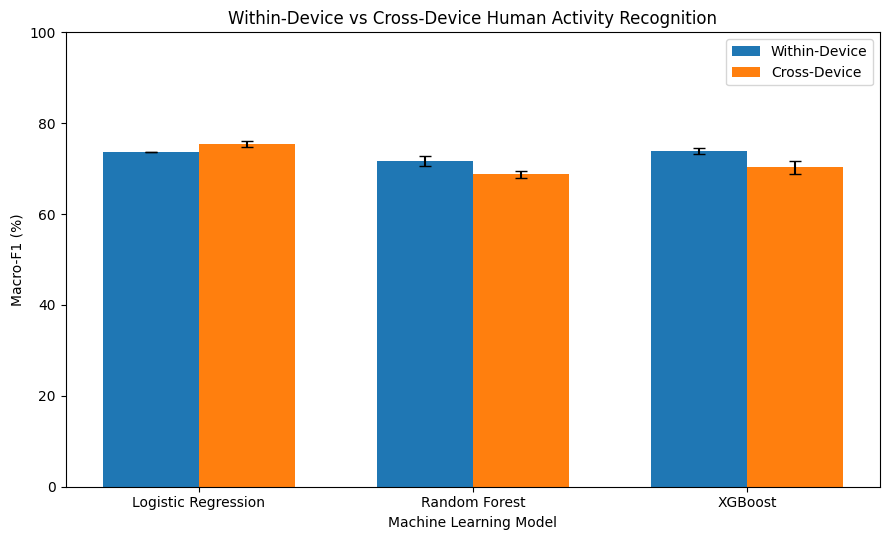

Final Figure 1 saved:
/content/drive/MyDrive/ML_Project/Figure_1_Within_vs_Cross_MacroF1.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load final comparison results
comparison = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "within_vs_cross_device_comparison.csv"
)

# Calculate model-level means
model_comparison = (
    comparison
    .groupby("Model")
    .agg(
        Within_F1=("Within_F1", "mean"),
        Within_Std=("Within_Std", "mean"),
        Cross_F1=("Cross_F1", "mean"),
        Cross_Std=("Cross_Std", "mean")
    )
    .reset_index()
)

# Create figure
fig, ax = plt.subplots(figsize=(9, 5.5))

x = range(len(model_comparison))
width = 0.35

ax.bar(
    [i - width / 2 for i in x],
    model_comparison["Within_F1"],
    width,
    yerr=model_comparison["Within_Std"],
    capsize=4,
    label="Within-Device"
)

ax.bar(
    [i + width / 2 for i in x],
    model_comparison["Cross_F1"],
    width,
    yerr=model_comparison["Cross_Std"],
    capsize=4,
    label="Cross-Device"
)

ax.set_xticks(list(x))
ax.set_xticklabels(model_comparison["Model"])

ax.set_xlabel("Machine Learning Model")
ax.set_ylabel("Macro-F1 (%)")

ax.set_title(
    "Within-Device vs Cross-Device Human Activity Recognition"
)

ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()

figure1_path = (
    "/content/drive/MyDrive/ML_Project/"
    "Figure_1_Within_vs_Cross_MacroF1.png"
)

plt.savefig(
    figure1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final Figure 1 saved:")
print(figure1_path)

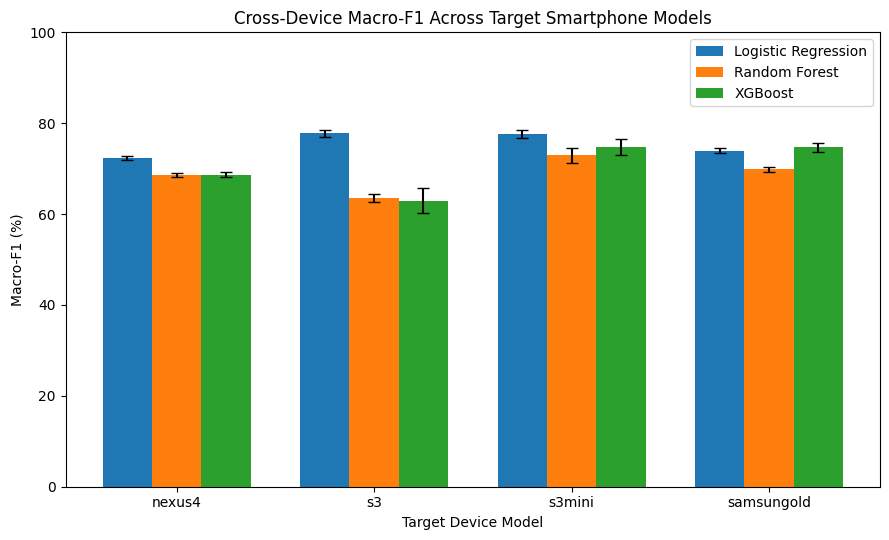

Final Figure 2 saved:
/content/drive/MyDrive/ML_Project/Figure_2_Cross_Device_Device_Comparison.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load final comparison results
comparison = pd.read_csv(
    "/content/drive/MyDrive/ML_Project/"
    "within_vs_cross_device_comparison.csv"
)

# Create figure
fig, ax = plt.subplots(figsize=(9, 5.5))

devices = [
    "nexus4",
    "s3",
    "s3mini",
    "samsungold"
]

models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

x = range(len(devices))
width = 0.25

for i, model in enumerate(models):

    model_data = (
        comparison[
            comparison["Model"] == model
        ]
        .set_index("Test_Model")
        .loc[devices]
    )

    positions = [
        value + (i - 1) * width
        for value in x
    ]

    ax.bar(
        positions,
        model_data["Cross_F1"],
        width,
        yerr=model_data["Cross_Std"],
        capsize=4,
        label=model
    )

ax.set_xticks(list(x))
ax.set_xticklabels(devices)

ax.set_xlabel("Target Device Model")
ax.set_ylabel("Macro-F1 (%)")

ax.set_title(
    "Cross-Device Macro-F1 Across Target Smartphone Models"
)

ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()

figure2_path = (
    "/content/drive/MyDrive/ML_Project/"
    "Figure_2_Cross_Device_Device_Comparison.png"
)

plt.savefig(
    figure2_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final Figure 2 saved:")
print(figure2_path)